## **Inference Notebook for Clustering and Classification using Credit Card Spending Data**

#### By: John Adrian T. Ada

---
### **Abstract** 

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import math

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (silhouette_score, 
                            silhouette_samples, 
                            calinski_harabasz_score, 
                            davies_bouldin_score)
import umap
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

import mlflow
import mlflow.sklearn

mlflow.sklearn.autolog()
#mlflow server --port 8080

np.random.seed(42)

C:\Users\adaad\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Methods**


---
### **0. Dataset Information**

Dataset and Source: Credit Card Dataset for Clustering (Uploaded by Arjun Bhasin on Kaggle)

https://www.kaggle.com/datasets/arjunbhasin2013/ccdata 


The dataset used summarizes the usage behavior of 8950 active credit card holders over a six-month period with 18 behavioral variables. The following is the Data Dictionary for Credit Card dataset:

| Column Name | Description |
|---|---|
| CUST_ID | Identification of Credit Card holder (Categorical) |
| BALANCE | Balance amount left in their account to make purchases |
| BALANCE_FREQUENCY | How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated) |
| PURCHASES | Amount of purchases made from account |
| ONEOFF_PURCHASES | Maximum purchase amount done in one-go |
| INSTALLMENTS_PURCHASES | Amount of purchase done in installment |
| CASH_ADVANCE | Cash in advance given by the user |
| PURCHASES_FREQUENCY | How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased) |
| ONEOFFPURCHASESFREQUENCY | How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased) |
| PURCHASESINSTALLMENTSFREQUENCY | How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done) |
| CASHADVANCEFREQUENCY | How frequently the cash in advance being paid |
| CASHADVANCETRX | Number of Transactions made with "Cash in Advanced" |
| PURCHASES_TRX | Number of purchase transactions made |
| CREDIT_LIMIT | Limit of Credit Card for user |
| PAYMENTS | Amount of Payment done by user |
| MINIMUM_PAYMENTS | Minimum amount of payments made by user |
| PRCFULLPAYMENT | Percent of full payment paid by user |
| TENURE | Tenure of credit card service for user |

In this project, it was used for consumer segmentation using unsupervised Machine Learning such as Clustering to determine different types of consumers before using Supervised Machine Learning to predict the labels determined from clustering. 

---
### **1. Data Loading**


In [2]:
df = pd.read_csv(r'../cc-dataset/CC GENERAL.csv')

print(df.columns)
df.head()

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


Some notes:
- No Negative Values for all columns, as expected
- High Standard Deviation, and thus high Variance, for most of the columns with a high range
- There are a missing values, seen in the count column. 
- Large disparity between the mean and median (50%) for the columns with a high range and high variance, suggesting that there are outliers. 
- Although CASH ADVANCE FREQUENCY has a range of [0, 1.5], nothing from the data description implies that there is anything wrong with this. All columns stayed within their expected range, usually [0,1]

In [5]:
int_cols = list(df.select_dtypes(include=['int64']).columns)
for col in int_cols:
    print(col)
    print(df[col].unique())

CASH_ADVANCE_TRX
[  0   4   1   3   6  13   5  16  10   2  11   7  12  37  27  23  21  14
  40   8   9  26  15  18  28  24  20  17  22  31 123  52  51  62  19  25
  30  29  53  45  43  42 107  38  56  39  32  33  50  34  63  36 110  47
  48  71  35  93  80  44  61  46  49  69  41]
PURCHASES_TRX
[  2   0  12   1   8  64   5   3   6  26  11   9  92  17  13  45  14  41
  27  20  87  18   4  42  61  33   7  50  22  23  60  46  75  31  10  34
  81  25  85 217  19  52 216  97  24  77 130  90  44  39  15  30  36 123
 151  21 101  49  98  28  84  93  72  38  99  62  48  16  32  51  74  29
  59  76  47 126 229  40 103 121 157 114  53  83  43  54 222  66 141  37
  79  70  80 194 117 100 111  67 219  55 152 104 182  88  82  71  78  35
 122 105 108  69 175 135  91  65  68 119  63 140 113 358  58 248 129  56
  89  57 139 176 136 195  73 109 208 115 110 147 273 102 185 171 168 232
  95  86 148 112 128 254 198 298 154 116 142 131 347 204 200  94 118 344
 162 308 199 309  96 274 224 143 133 127 186]
T

In [6]:
null_df = pd.DataFrame({'Missing Values': df.isnull().sum(), 'Percentage': round(df.isnull().sum() / df.shape[0] * 100, 2)})

null_df.sort_values('Missing Values', ascending=False)

,Missing Values,Percentage
MINIMUM_PAYMENTS,313,3.50
CREDIT_LIMIT,1,0.01
BALANCE,0,0.00
CUST_ID,0,0.00
BALANCE_FREQUENCY,0,0.00
PURCHASES,0,0.00
CASH_ADVANCE,0,0.00
PURCHASES_FREQUENCY,0,0.00
ONEOFF_PURCHASES,0,0.00
INSTALLMENTS_PURCHASES,0,0.00


---
#### **2. Exploratory Data Analysis**

count     8637.000000
mean       864.206542
std       2372.446607
min          0.019163
25%        169.123707
50%        312.343947
75%        825.485459
max      76406.207520
Name: MINIMUM_PAYMENTS, dtype: float64


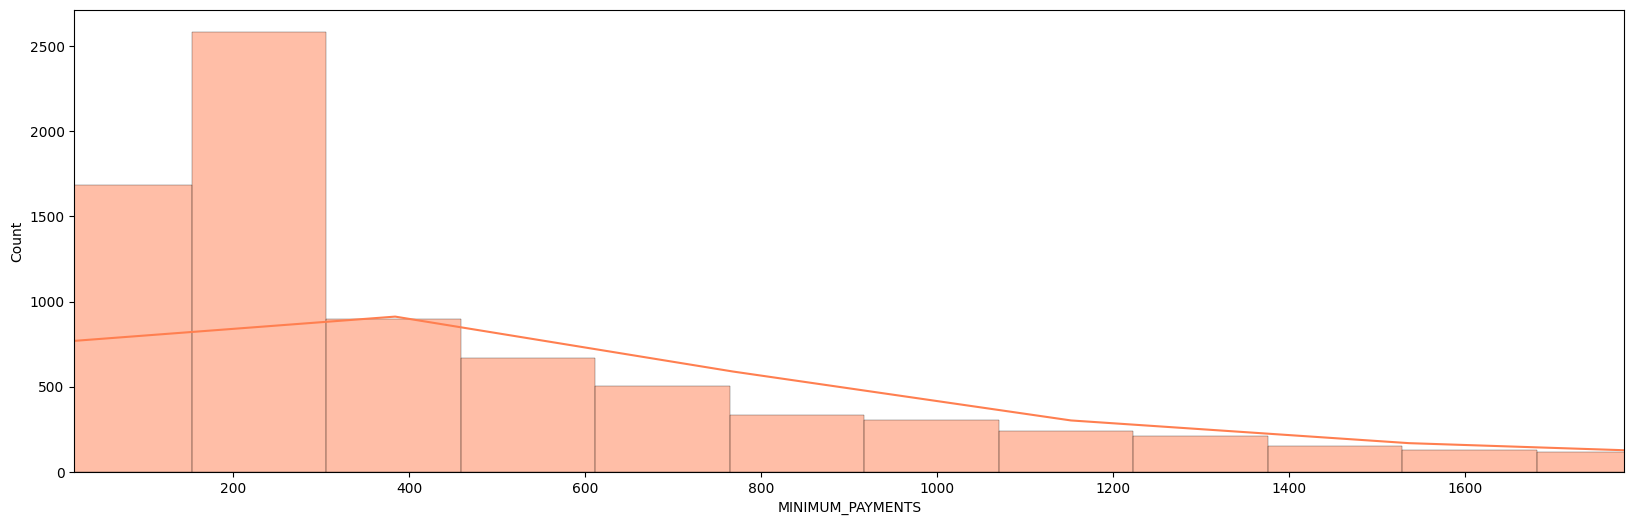

In [7]:
#graph minimum payments
plt.figure(figsize=(20, 6))
p90 = np.percentile(df['MINIMUM_PAYMENTS'], 25)
sns.histplot(df['MINIMUM_PAYMENTS'], kde=True, bins=500, color='coral')
plt.xlim(df['MINIMUM_PAYMENTS'].quantile(0.01), df['MINIMUM_PAYMENTS'].quantile(0.9))

print(df['MINIMUM_PAYMENTS'].describe())

Most of the null values come from the Minimum Payments column. According to the Data Dictionary, it is the Mininum Payments made by a user. By definition, it always has to be less than or equal to the Payments column. From the succeeding cells, Minimum Payments and Credit Limit, the two columns with null values, are continuous and right-skewed. This means that the Median, not the Mean, would be preferred for simple imputing if imputation is done later on. The histplot above shows the Minimum Payments zoomed in on the 90th percentile. Three-quarters of observations have a Minimum_Payments value of 825.50 or under. 

In [8]:
df[df.isnull().any(axis=1)].head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.0,12
45,C10047,2242.311686,1.000000,437.00,97.00,340.0,184.648692,0.333333,0.083333,0.333333,0.166667,2,5,2400.0,0.000000,NaN,0.0,12
47,C10049,3910.111237,1.000000,0.00,0.00,0.0,1980.873201,0.000000,0.000000,0.000000,0.500000,7,0,4200.0,0.000000,NaN,0.0,12
54,C10056,6.660517,0.636364,310.00,0.00,310.0,0.000000,0.666667,0.000000,0.666667,0.000000,0,8,1000.0,417.016763,NaN,0.0,12
55,C10057,1311.995984,1.000000,1283.90,1283.90,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,6,6000.0,0.000000,NaN,0.0,12
56,C10058,3625.218146,1.000000,313.27,313.27,0.0,668.468743,0.250000,0.250000,0.000000,0.416667,5,4,4000.0,0.000000,NaN,0.0,12
63,C10065,7.152356,0.090909,840.00,840.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1600.0,0.000000,NaN,0.0,12
93,C10098,1307.717841,1.000000,405.60,405.60,0.0,0.000000,0.166667,0.166667,0.000000,0.000000,0,2,2400.0,0.000000,NaN,0.0,12
94,C10099,2329.485768,1.000000,213.34,213.34,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,3,2400.0,0.000000,NaN,0.0,12
97,C10102,3505.671311,1.000000,0.00,0.00,0.0,1713.984305,0.000000,0.000000,0.000000,0.500000,6,0,4000.0,0.000000,NaN,0.0,12


Since CUST_ID is the unique identifier for the dataset, duplicate records can be checked using this column

In [9]:
print(f"Number of duplicate records: {df['CUST_ID'].duplicated().sum()}")

Number of duplicate records: 0


In [10]:
def plot_all_features_grid(dataframe, max_cols=9):
    """
    Calculates a grid and plots all features in a single large figure.
    Works for any number of dimensions by dynamically calculating grid shape.
    
    Parameters:
    - dataframe: The pandas DataFrame containing features to plot.
    - max_cols: The maximum number of columns for the plot grid.
    """
    print("Generating dynamic grid plot...")
    num_features = len(dataframe.columns)
    
    # Guard clause in case an empty dataframe is passed
    if num_features == 0:
        print("No features to plot.")
        return

    # Don't create more grid columns than actual features
    grid_cols = min(num_features, max_cols)
    grid_rows = math.ceil(num_features / grid_cols)
    
    # Dynamically scale the figure size (approx 3x2.5 inches per subplot)
    fig_width = grid_cols * 3
    fig_height = grid_rows * 2.5
    
    fig, axes = plt.subplots(nrows=grid_rows, ncols=grid_cols, figsize=(fig_width, fig_height))
    
    # Flatten axes array for easy iteration (handles 1x1 case safely)
    if num_features == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    for i, col in enumerate(dataframe.columns):
        # Plot on the specific subplot axis
        sns.histplot(dataframe[col], kde=True, bins=20, ax=axes[i], color='coral')
        
        axes[i].set_title(col, fontsize=10)
        axes[i].set_xlabel("") # Remove x-labels to save space
        axes[i].set_ylabel("") # Remove y-labels to save space
        axes[i].tick_params(axis='both', which='major', labelsize=8)

    # Clean up: hide any extra empty subplots if the grid isn't perfectly filled
    for j in range(num_features, len(axes)):
        fig.delaxes(axes[j])
        
    # Adjust layout to prevent title/tick overlap
    plt.tight_layout()
    plt.show()

Generating dynamic grid plot...


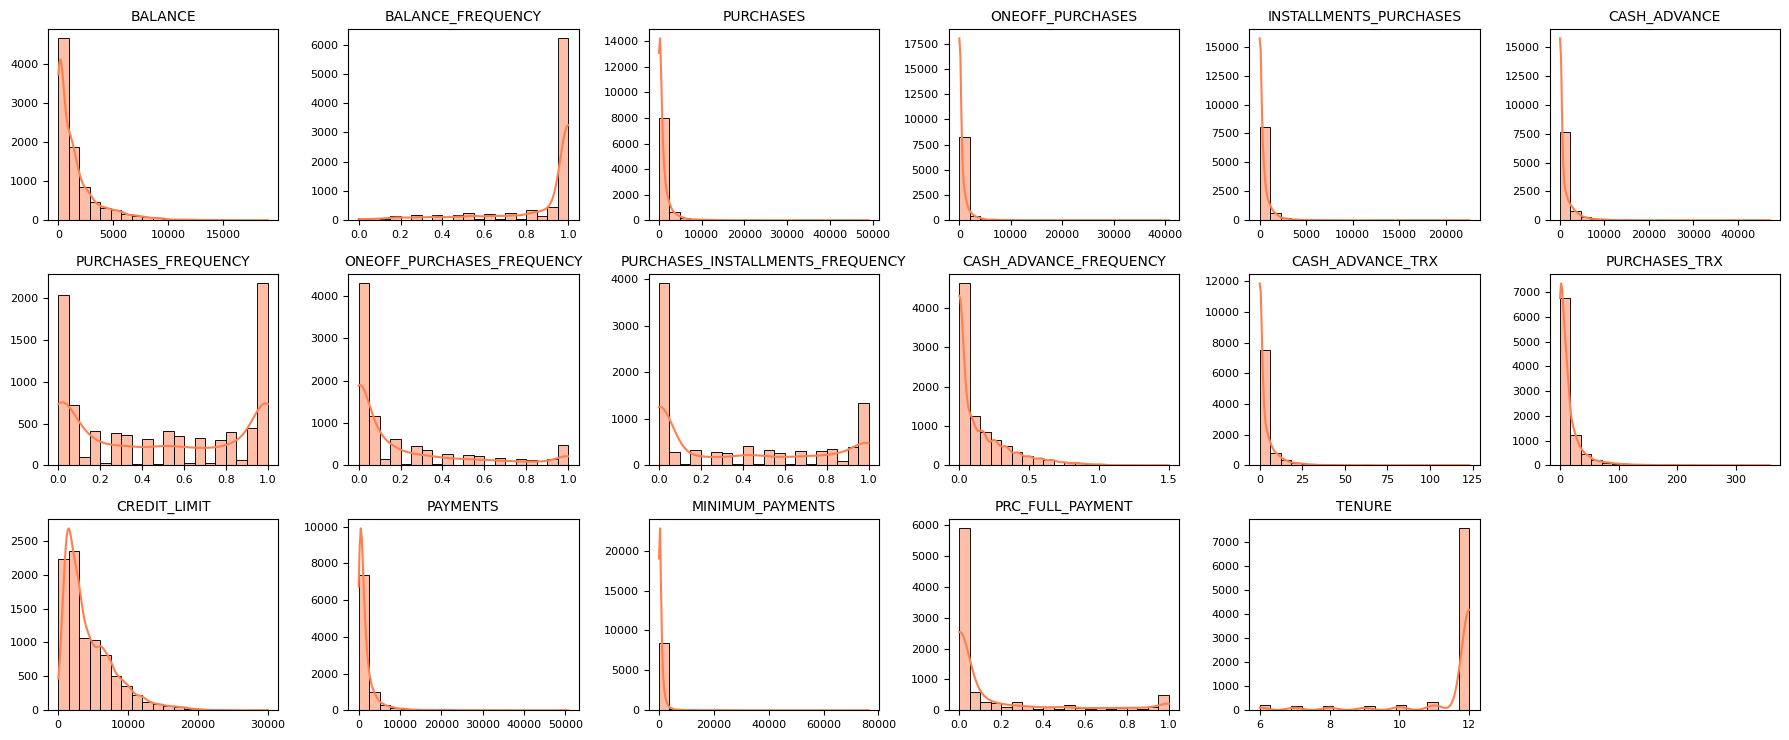

In [11]:
plot_all_features_grid(df.drop('CUST_ID', axis=1), 6)

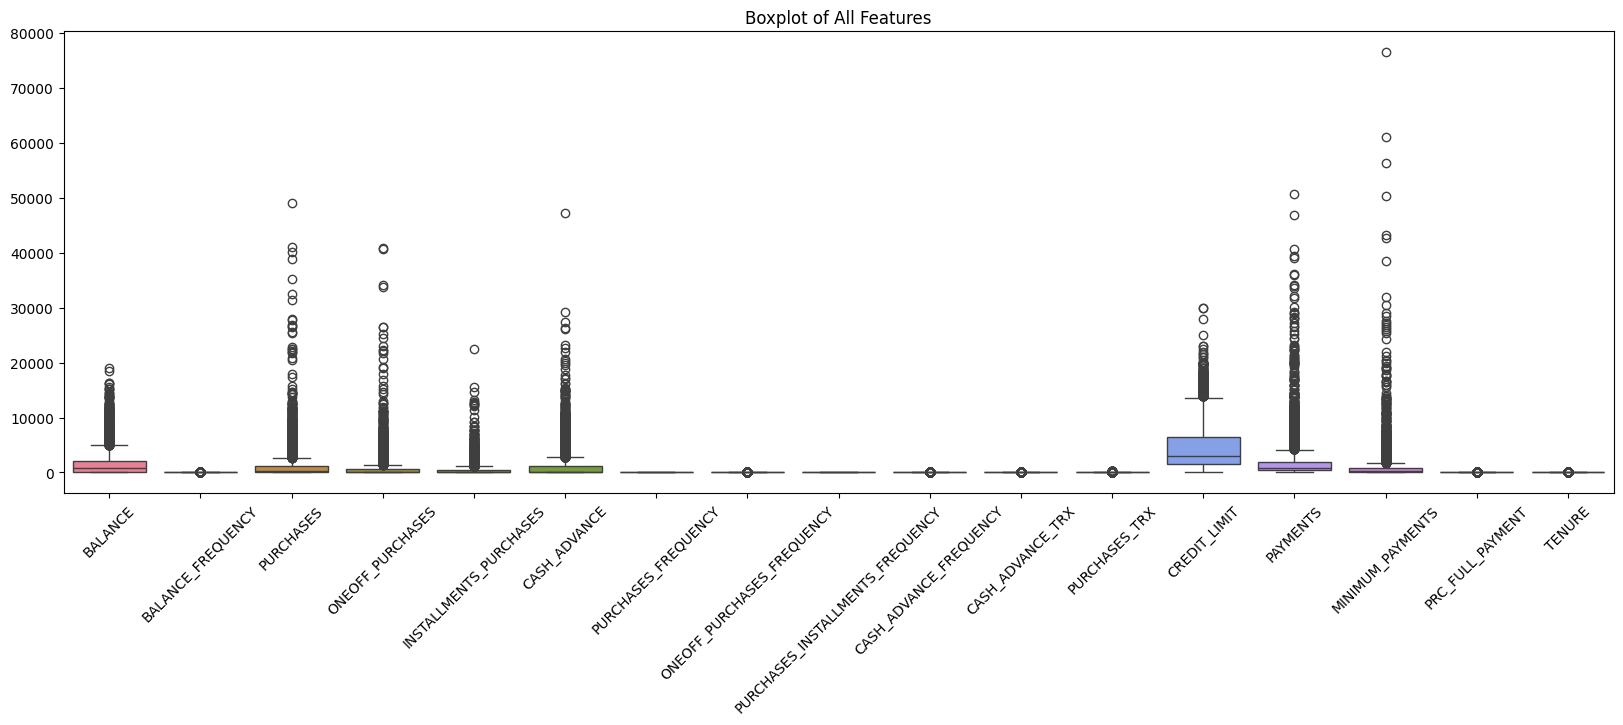

In [12]:
numerical_cols = df.select_dtypes(include=["float64", "int64"])
plt.figure(figsize=(20, 6))
sns.boxplot(numerical_cols)
plt.xticks(rotation=45)  
plt.title("Boxplot of All Features")
plt.show()

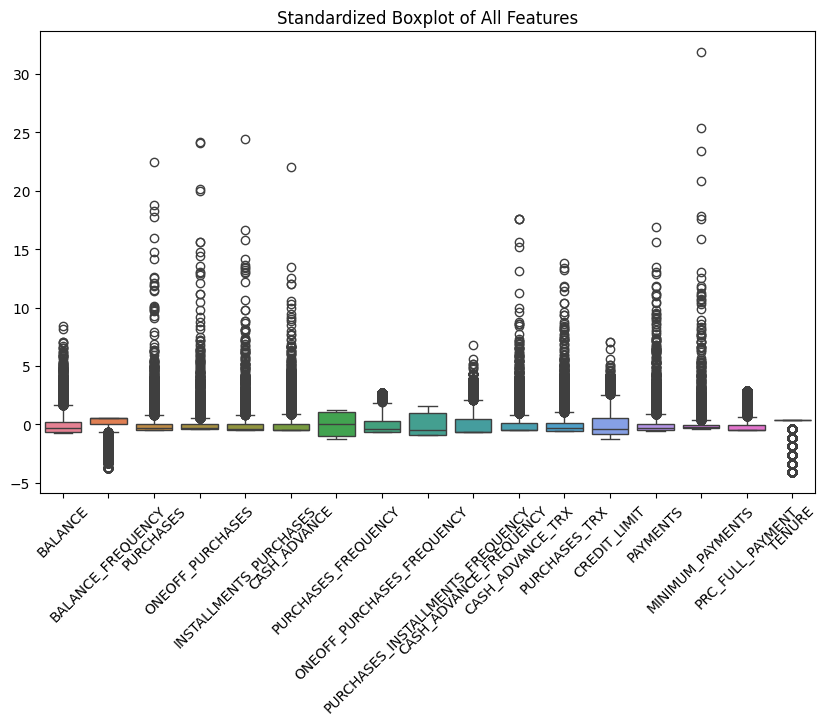

In [13]:
#standardized
numerical_cols = df.select_dtypes(include=["float64", "int64"])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_cols)
scaled_df = pd.DataFrame(scaled_data, columns=numerical_cols.columns)

plt.figure(figsize=(10, 6))
sns.boxplot(data=scaled_df)
plt.xticks(rotation=45)  
plt.title("Standardized Boxplot of All Features")
plt.show()

Most of the features are right-skewed, particularly features relating to money or wealth such as Purchases, Balance, Credit Limit, and Payments. Thus, it is expected that there are significantly less high spenders due to the low frequency (y-axis) of the aforementioned features that exhibit the higher values (x-axis) of their range. 

Plenty of outliers, plenty of right skewed features as seen in the table of Descriptive Statistics and Bar plots. 

<Axes: >

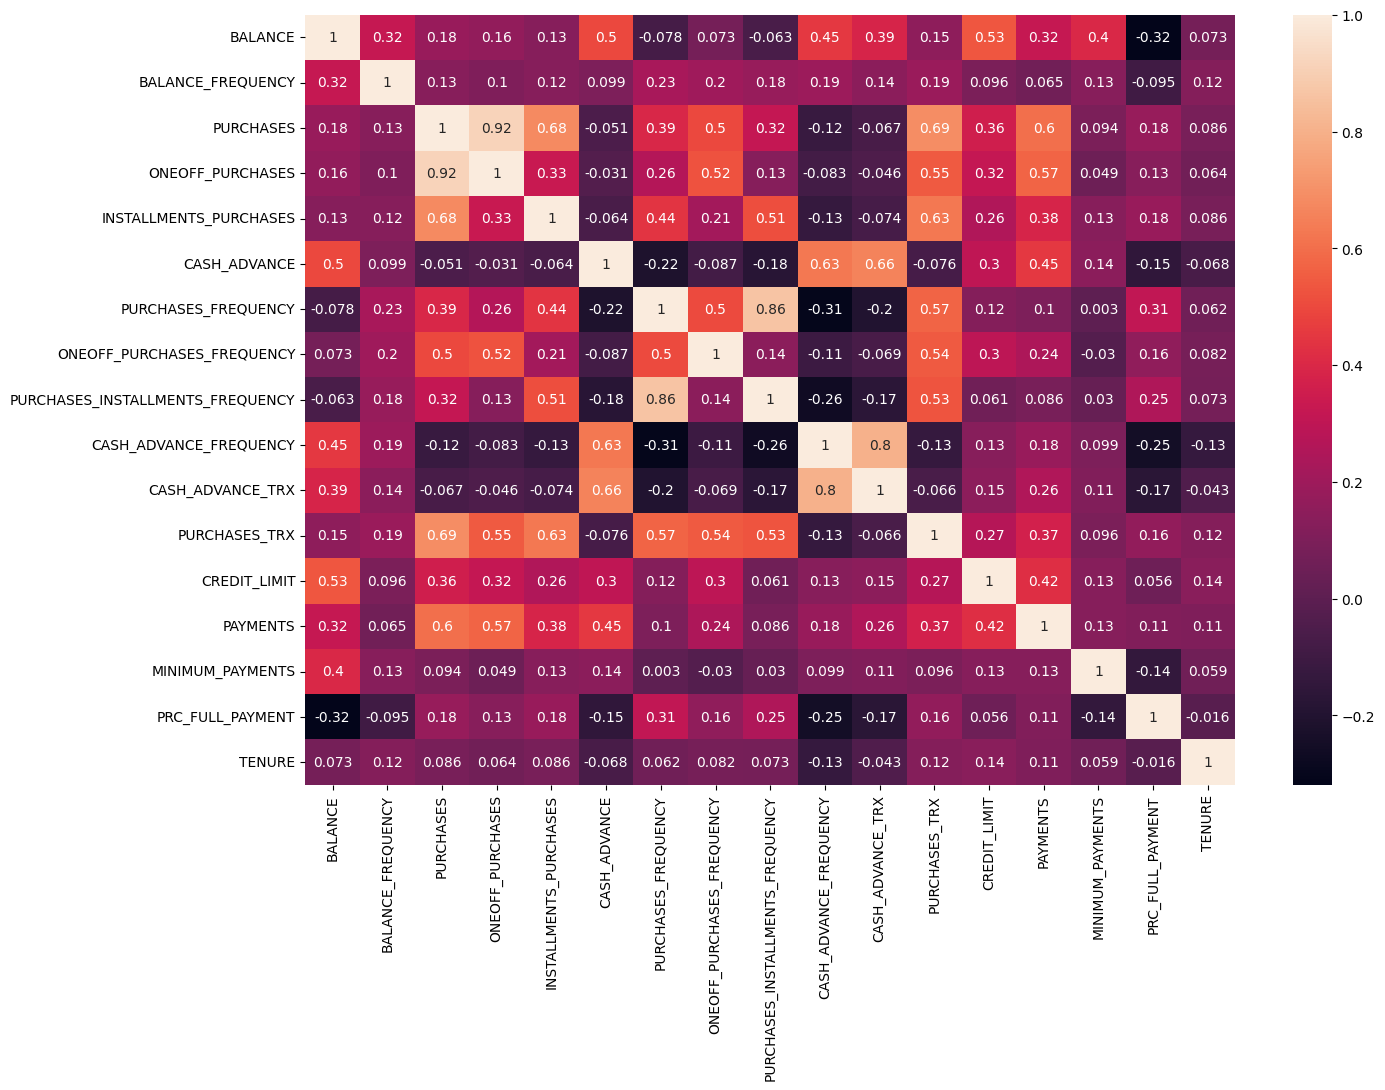

In [14]:
#heatmap correlation
plt.figure(figsize=(15, 10))
sns.heatmap(numerical_cols.corr(), annot=True)

In [15]:
#print max correlation coefficient that are less than 1
masked_corr = numerical_cols.corr().replace(1.0, np.nan)
print(masked_corr.max().sort_values(ascending=False))

PURCHASES                           0.916845
ONEOFF_PURCHASES                    0.916845
PURCHASES_INSTALLMENTS_FREQUENCY    0.862934
PURCHASES_FREQUENCY                 0.862934
CASH_ADVANCE_TRX                    0.799561
CASH_ADVANCE_FREQUENCY              0.799561
PURCHASES_TRX                       0.689561
INSTALLMENTS_PURCHASES              0.679896
CASH_ADVANCE                        0.656498
PAYMENTS                            0.603264
ONEOFF_PURCHASES_FREQUENCY          0.544869
BALANCE                             0.531283
CREDIT_LIMIT                        0.531283
MINIMUM_PAYMENTS                    0.398684
BALANCE_FREQUENCY                   0.322412
PRC_FULL_PAYMENT                    0.305802
TENURE                              0.139167
dtype: float64


---
### **2.1. Imputation Techniques**

The mean and even median cannot be used for imputing for the missing values of Minimum Payments (313). Using the mean would be problematic because Minimum Payments is heavily right-skewed, with the mean being nearly three times that of the median (864.21 to 312.34). While the median would be more robust to outlers, the imputed value is only based on the Minimum Payments column, it does not take into consideration what a typical value would be given the values of the other columns. Even if a rule or constraint would be added such that Minimum Payments will always be less than or Equal to the corresponding value of the Payments column for the same row, the distribution can still be distorted and thus the variance would also be distorted. Median imputation may save time and be less computationally complex, especially given the few number of rows relative to the size of the data (The missing rows only account for about 3.5% of the data), its still worth using more robust methods.

Hence, for this demonstration two methods will be used: K-Nearest Neighbors (KNN) and Regression-Based Imputation. KNN takes into consideration the other variables and preserves the distribution and shape of Minimum Payments. Regression-Based imputation makes use of a simple linear model to predict the missing values. This is done by splitting the data into two groups: the first group contains all observations with no missing values, which is where the model is trained on. Then the observations with missing values are predicted by the trained model. For this, Minimum Payments becomes the target variable. The two approaches represent Non-Parametric and Parametric approaches respectively. 

For these, a few pre-processing techniques are needed. 

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, median_absolute_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split

In [17]:
#drop the rows with missing values for "CREDIT_LIMIT"
df = df.dropna(subset=["CREDIT_LIMIT"])
df = df.drop(['CUST_ID'], axis=1)

In [18]:
target_col = "MINIMUM_PAYMENTS"
feature_cols = list(df.columns[df.columns != target_col])

skewed_cols = feature_cols + [target_col]
data = df[feature_cols + [target_col]].copy()

for col in skewed_cols:
    data[col] = np.log1p(data[col].clip(lower=0))

print(len(df.columns), len(skewed_cols))


17 17


In [19]:
#validation split

known_idx = data[data[target_col].notna()].index.values

train_idx, val_idx = train_test_split(
    known_idx, test_size=0.2, random_state=42
)

y_val_true = data.loc[val_idx, target_col].copy()

In [20]:
#Evaluation metric
def evaluate_both_spaces(y_true_log, y_pred_log, label=""):
    y_true_log = np.asarray(y_true_log)
    y_pred_log = np.asarray(y_pred_log)

    rmse_log = root_mean_squared_error(y_true_log, y_pred_log)
    mae_log = mean_absolute_error(y_true_log, y_pred_log)

    y_true_lin = np.expm1(y_true_log)
    y_pred_lin = np.expm1(y_pred_log)
    y_pred_lin = np.clip(y_pred_lin, a_min=0, a_max=None)  # no negative payments

    rmse_lin = root_mean_squared_error(y_true_lin, y_pred_lin)
    mae_lin = mean_absolute_error(y_true_lin, y_pred_lin)
    medae_lin = median_absolute_error(y_true_lin, y_pred_lin)

    print(f"{label}")
    print(f"Log space    : RMSE: {rmse_log:.4f} | MAE: {mae_log:.4f}")
    print(f"Linear space : RMSE: {rmse_lin:.2f} | MAE: {mae_lin:.2f} | MedAE: {medae_lin:.2f}")
    print()

    return {
        "label": label,
        "rmse_log": rmse_log, "mae_log": mae_log,
        "rmse_lin": rmse_lin, "mae_lin": mae_lin, "medae_lin": medae_lin
    }

---
#### **2.1.1 KNN Imputation**

In [21]:
def knn_cv_rmse(data, target_col, k, known_idx, n_splits=5, random_state=42):
    """CV RMSE (log space) over the known rows, used only for k selection."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    errors = []

    for _, test_pos in kf.split(known_idx):
        test_rows = known_idx[test_pos]

        data_masked = data.copy()
        true_vals = data_masked.loc[test_rows, target_col].copy()
        data_masked.loc[test_rows, target_col] = np.nan

        scaler = StandardScaler()
        scaled = pd.DataFrame(
            scaler.fit_transform(data_masked),
            columns=data_masked.columns, index=data_masked.index
        )

        imputer = KNNImputer(n_neighbors=k)
        imputed_scaled = imputer.fit_transform(scaled)
        imputed = pd.DataFrame(
            scaler.inverse_transform(imputed_scaled),
            columns=data_masked.columns, index=data_masked.index
        )

        rmse = root_mean_squared_error(true_vals, imputed.loc[test_rows, target_col])
        errors.append(rmse)

    return np.mean(errors)

In [22]:
# Use only the training portion of known_idx for k selection (val stays untouched)
train_only_idx = train_idx.copy()

k_candidates = [3, 5, 7, 9, 11, 13, 15, 17]
cv_results = {}
for k in k_candidates:
    score = knn_cv_rmse(data, target_col, k, train_only_idx)
    cv_results[k] = score
    print(f"k={k:>2} | CV RMSE (log-space) = {score:.4f}")

best_k = min(cv_results, key=cv_results.get)
print(f"\nBest k selected: {best_k}\n")

k= 3 | CV RMSE (log-space) = 0.6819
k= 5 | CV RMSE (log-space) = 0.6639
k= 7 | CV RMSE (log-space) = 0.6633
k= 9 | CV RMSE (log-space) = 0.6628
k=11 | CV RMSE (log-space) = 0.6640
k=13 | CV RMSE (log-space) = 0.6669
k=15 | CV RMSE (log-space) = 0.6678
k=17 | CV RMSE (log-space) = 0.6694

Best k selected: 9



In [23]:
#use the shared validation split
data_masked_knn = data.copy()
data_masked_knn.loc[val_idx, target_col] = np.nan  # mask val rows only

scaler_knn = StandardScaler()
scaled_knn = pd.DataFrame(
    scaler_knn.fit_transform(data_masked_knn),
    columns=data_masked_knn.columns, index=data_masked_knn.index
)

knn_imputer_final = KNNImputer(n_neighbors=best_k)
imputed_scaled_knn = knn_imputer_final.fit_transform(scaled_knn)
imputed_knn = pd.DataFrame(
    scaler_knn.inverse_transform(imputed_scaled_knn),
    columns=data_masked_knn.columns, index=data_masked_knn.index
)

y_val_pred_knn = imputed_knn.loc[val_idx, target_col]
results_knn = evaluate_both_spaces(y_val_true, y_val_pred_knn, label="KNN Imputation")

KNN Imputation
Log space    : RMSE: 0.6554 | MAE: 0.4403
Linear space : RMSE: 1948.72 | MAE: 486.10 | MedAE: 101.92



---
#### **1.1.2 Regression Imputation**

Using the same variables "target_col" as the target variable and "right_skewed_columns" as the feature set, a linear regression model is trained to predict the missing values. 

In [24]:
X_train = data.loc[train_idx, feature_cols]
y_train = data.loc[train_idx, target_col]
X_val = data.loc[val_idx, feature_cols]

scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_val_scaled = scaler_reg.transform(X_val)

reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)

y_val_pred_reg = reg_model.predict(X_val_scaled)
results_reg = evaluate_both_spaces(y_val_true, y_val_pred_reg, label="Linear Regression Imputation")

2026/08/29 21:07:25 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'bad6bd68bbb34ad991e8b13945a0f2b2', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:07:25 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/08/29 21:07:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression Imputation
Log space    : RMSE: 0.6524 | MAE: 0.4677
Linear space : RMSE: 1930.89 | MAE: 475.58 | MedAE: 114.68



---
#### **1.1.3 Comparison and Final Imputation**

To make sense of the values for Mean Absolute Error, it is compared to the median of the target column. 

In [25]:
comparison = pd.DataFrame([results_knn, results_reg]).set_index("label")
print(comparison)

print(f"\nMedian of Minimum Payments:{df['MINIMUM_PAYMENTS'].median()}")

best_method = comparison["mae_lin"].idxmin()
print(f"\nBest method based on linear-space MAE: {best_method}")

                              rmse_log   mae_log     rmse_lin     mae_lin  \
label                                                                       
KNN Imputation                0.655392  0.440327  1948.717217  486.102248   
Linear Regression Imputation  0.652369  0.467731  1930.892271  475.575779   

                               medae_lin  
label                                     
KNN Imputation                101.920866  
Linear Regression Imputation  114.677267  

Median of Minimum Payments:312.4522915

Best method based on linear-space MAE: Linear Regression Imputation


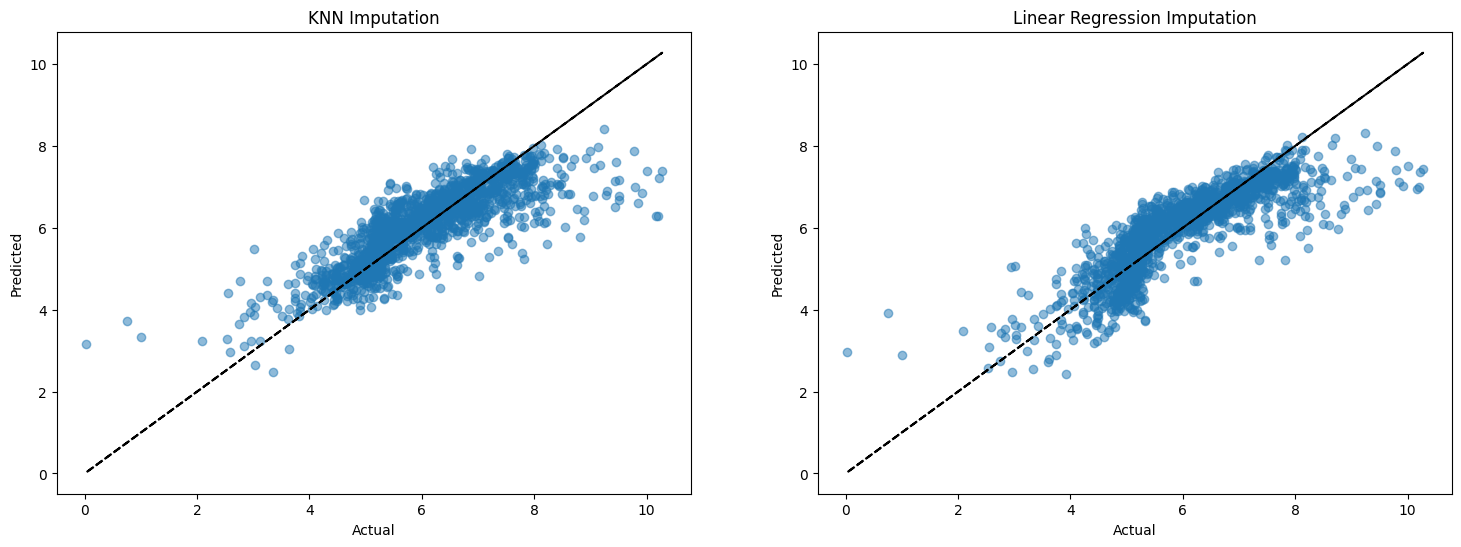

In [26]:
#plot predicted vs actual

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for i, (y_true, y_pred, label) in enumerate([
    (y_val_true, y_val_pred_knn, "KNN Imputation"),
    (y_val_true, y_val_pred_reg, "Linear Regression Imputation")
]):
    axes[i].plot(y_true, y_pred, "o", alpha=0.5)
    axes[i].plot(y_true, y_true, "k--")
    axes[i].set_xlabel("Actual")
    axes[i].set_ylabel("Predicted")
    axes[i].set_title(label)

Given these results, using KNN or Regression imputation is considerably worse than using median imputation instead. The outliers have a significant pull on mean or simply because of weak feature relationships. 

In [27]:
#Median imputation on the missing data of df

df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8949 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8949 non-null   float64
 1   BALANCE_FREQUENCY                 8949 non-null   float64
 2   PURCHASES                         8949 non-null   float64
 3   ONEOFF_PURCHASES                  8949 non-null   float64
 4   INSTALLMENTS_PURCHASES            8949 non-null   float64
 5   CASH_ADVANCE                      8949 non-null   float64
 6   PURCHASES_FREQUENCY               8949 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8949 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8949 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8949 non-null   float64
 10  CASH_ADVANCE_TRX                  8949 non-null   int64  
 11  PURCHASES_TRX                     8949 non-null   int64  
 12  CREDIT_LIMI

For the suceeding steps, the data to be used is scaled and ths right-skewed columns are log-transformed.

In [28]:
#log transform
df1 = df.copy()
for col in df1.columns:
    df1[col] = np.log1p(df1[col].clip(lower=0))

scaler = StandardScaler()
scaler.set_output(transform="pandas")
scaled_df = scaler.fit_transform(df1)

scaled_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.205498,-0.149181,-0.113732,-0.987198,0.394362,-0.930636,-0.747076,-0.732543,-0.674357,-0.724294,-0.810038,-0.579693,-1.447095,-0.825080,-0.830453,-0.556409,0.347127
1,0.948821,0.179354,-1.680213,-0.987198,-1.087586,1.528788,-1.302995,-0.732543,-0.958359,0.699585,0.784546,-1.379434,0.925997,1.065109,0.908196,0.391881,0.347127
2,0.824885,0.492603,0.600600,1.061910,-1.087586,-0.930636,1.196721,2.466616,-0.958359,-0.724294,-0.810038,0.487735,1.010161,-0.119646,0.450254,-0.556409,0.347127
3,0.624529,-0.858641,0.827395,1.265665,-1.087586,0.564410,-1.014336,-0.363114,-0.958359,-0.213543,-0.123288,-0.874853,1.010161,-4.163779,-0.144341,-0.556409,0.347127
4,0.271106,0.492603,-0.708741,-0.114417,-1.087586,-0.930636,-1.014336,-0.363114,-0.958359,-0.724294,-0.810038,-0.874853,-1.224854,-0.065306,-0.352273,-0.556409,0.347127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,-1.379929,0.492603,0.266413,-0.987198,0.753993,-0.930636,1.196721,-0.732543,1.192296,-0.724294,-0.810038,0.037102,-1.447095,-0.525611,-1.715942,1.359659,-4.406443
8946,-1.568362,0.492603,0.276681,-0.987198,0.763707,-0.930636,1.196721,-0.732543,1.192296,-0.724294,-0.810038,0.037102,-1.447095,-0.629439,-0.144341,-0.556409,-4.406443
8947,-1.474137,-0.093302,0.027189,-0.987198,0.527678,-0.930636,0.882929,-0.732543,0.854123,-0.724294,-0.810038,-0.075113,-1.447095,-1.392116,-1.276314,0.498079,-4.406443
8948,-1.734100,-0.093302,-1.680213,-0.987198,-1.087586,0.086095,-1.302995,-0.732543,-0.958359,0.259343,0.278435,-1.379434,-2.291561,-1.661991,-1.605627,0.498079,-4.406443


Generating dynamic grid plot...


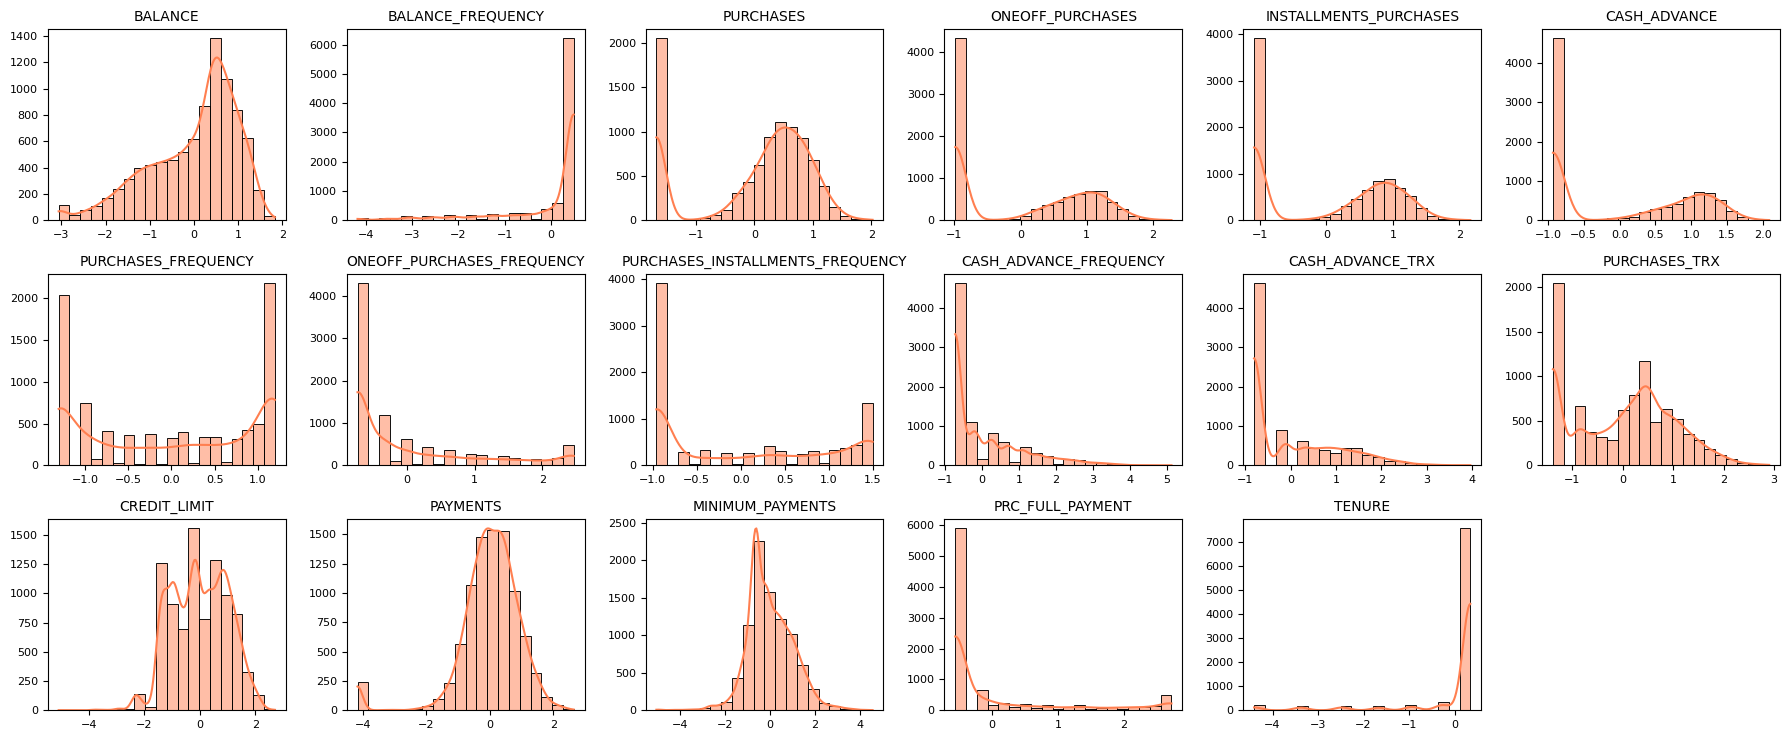

Generating dynamic grid plot...


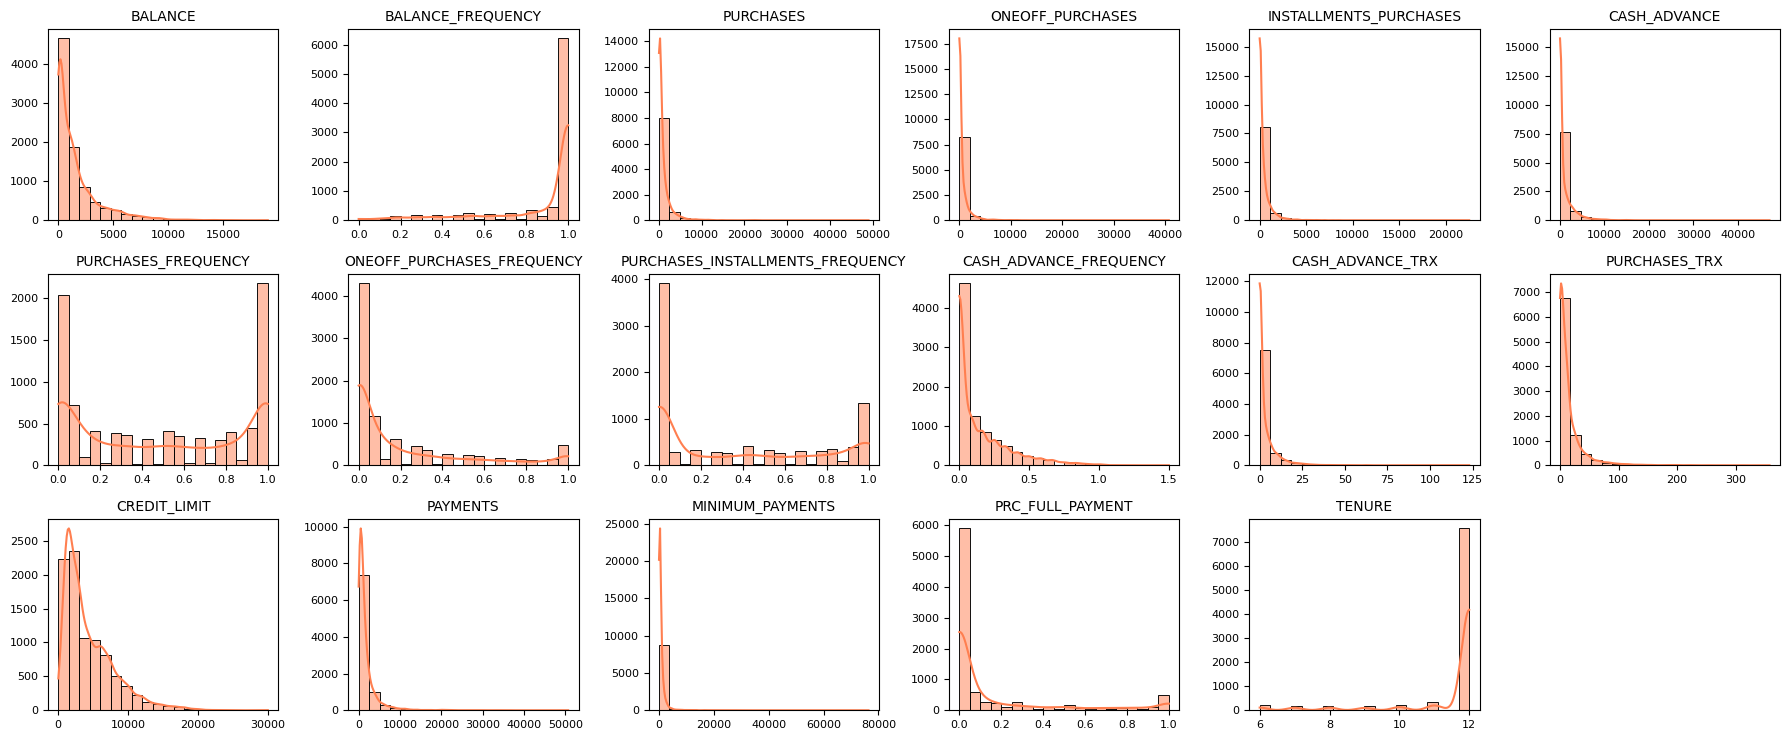

In [29]:
plot_all_features_grid(scaled_df, 6)
plot_all_features_grid(df, 6)

---
### **3. Dimensionality Reduction and Clustering**


#### **3.1 Obtaining the Optimal Number of Components for PCA and UMAP**

2026/08/29 21:07:37 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'd87f41803180436fb676074310eccafa', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:07:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:07:38 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:07:41 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model traini

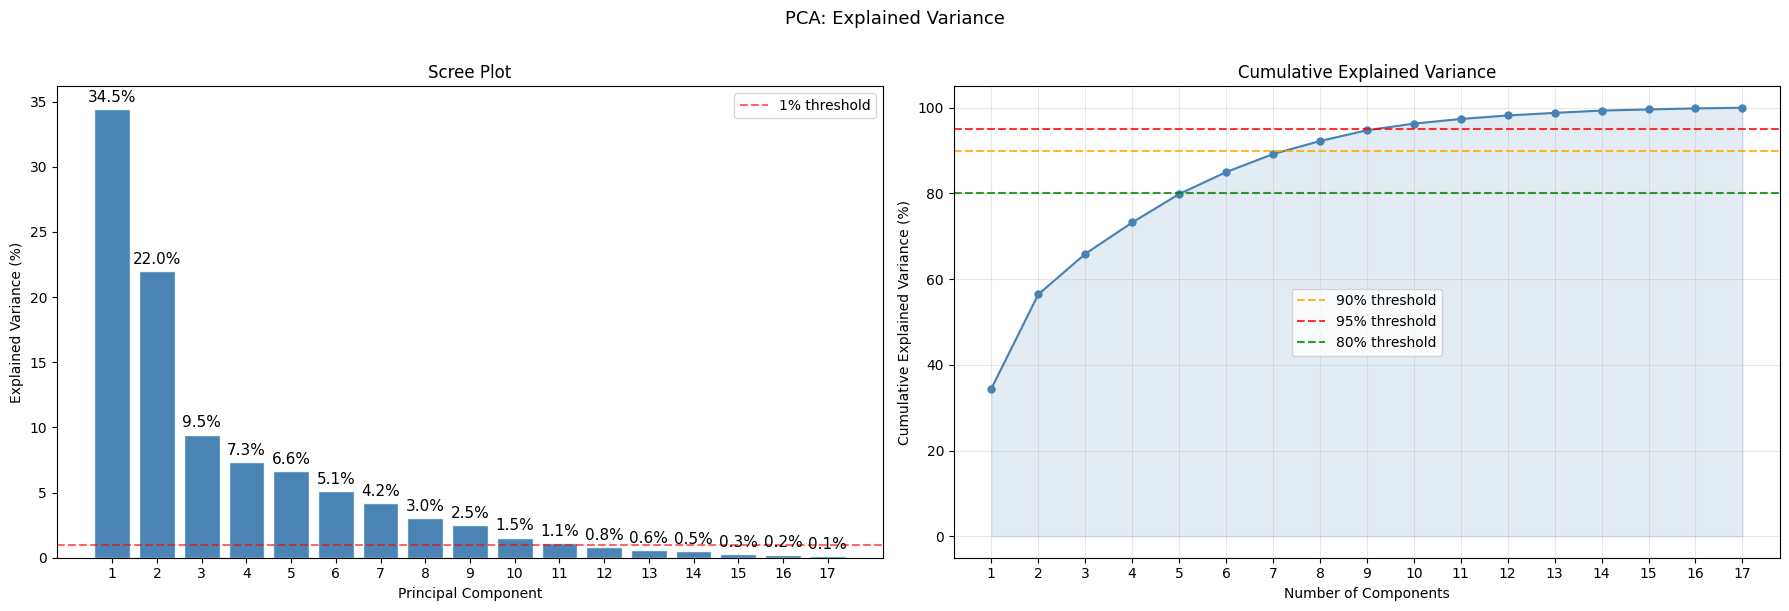

EXPLAINED VARIANCE BY COMPONENT

  PC01: 34.46%  |  Cumulative:  34.46%
  PC02: 22.00%  |  Cumulative:  56.45%
  PC03:  9.46%  |  Cumulative:  65.91%
  PC04:  7.32%  |  Cumulative:  73.23%
  PC05:  6.64%  |  Cumulative:  79.87%
  PC06:  5.12%  |  Cumulative:  84.99%
  PC07:  4.20%  |  Cumulative:  89.19%
  PC08:  3.04%  |  Cumulative:  92.23%
  PC09:  2.52%  |  Cumulative:  94.75%
  PC10:  1.54%  |  Cumulative:  96.29%

  Components needed to explain 80% of variance: 6
  Components needed to explain 90% of variance: 8
  Components needed to explain 95% of variance: 10
  Feature count: 17
  Compression ratio (90% threshold): 8/30 = 26.7%
  For Reference, the number of features (excluding CUST_ID) is 17


In [30]:
pca = PCA(random_state=42)
pca.fit(scaled_df)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scree plot
components = np.arange(1, len(pca.explained_variance_ratio_) + 1)
axes[0].bar(
    components, pca.explained_variance_ratio_ * 100,
    color='steelblue', edgecolor='white', alpha=0.85
)

bars = axes[0].bar(
    components, pca.explained_variance_ratio_ * 100,
    color='steelblue', edgecolor='white', alpha=0.85
)

axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].axhline(y=1, color='red', linestyle='--', alpha=0.6, label='1% threshold')
axes[0].legend()

axes[0].set_xticks(components)
axes[0].bar_label(bars, fmt='%.1f%%', padding=3, color='black', fontsize=11)

# Cumulative explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(components, cumvar, 'o-', color='steelblue', markersize=5)
axes[1].axhline(y=90, color='orange', linestyle='--', alpha=0.8, label='90% threshold')
axes[1].axhline(y=95, color='red', linestyle='--', alpha=0.8, label='95% threshold')
axes[1].axhline(y=80, color='green', linestyle='--', alpha=0.8, label='80% threshold')
axes[1].fill_between(components, cumvar, alpha=0.15, color='steelblue')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[1].set_xticks(components)

plt.suptitle('PCA: Explained Variance', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Report
print("EXPLAINED VARIANCE BY COMPONENT\n")
cumulative = 0
for i, var in enumerate(pca.explained_variance_ratio_[:10]):
    cumulative += var
    print(f"  PC{i+1:02d}: {var*100:5.2f}%  |  Cumulative: {cumulative*100:6.2f}%")

n_80 = np.argmax(cumvar >= 80) + 1
n_90 = np.argmax(cumvar >= 90) + 1
n_95 = np.argmax(cumvar >= 95) + 1
print()
print(f"  Components needed to explain 80% of variance: {n_80}")
print(f"  Components needed to explain 90% of variance: {n_90}")
print(f"  Components needed to explain 95% of variance: {n_95}")
print(f"  Feature count: {scaled_df.shape[1]}")
print(f"  Compression ratio (90% threshold): {n_90}/30 = {n_90/30:.1%}")
print(f"  For Reference, the number of features (excluding CUST_ID) is {scaled_df.shape[1]}")

2026/08/29 21:07:42 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '2d0245dd8d95438684b3161f43d986ac', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:07:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:07:42 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:07:46 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model traini

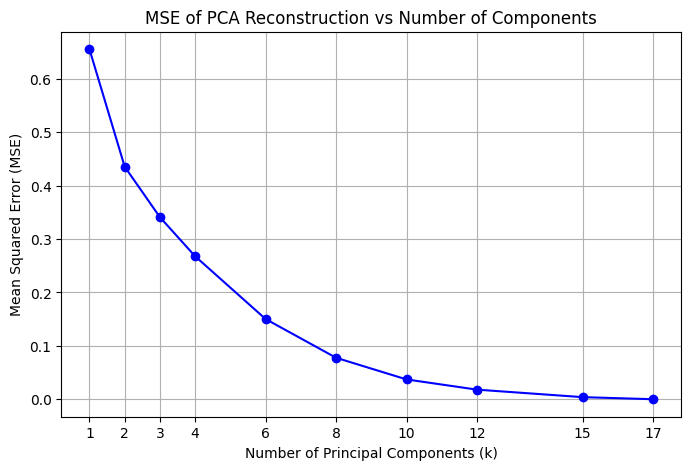

In [31]:
# PCA Reconstruction
k_values = [1, 2, 3, 4, 6, 8, 10, 12, 15, 17]
mse_list = []
mse_k2 = None

for k in k_values:
    pca = PCA(n_components=k, random_state=42)
    transformed = pca.fit_transform(scaled_df)
    reconstructed = pca.inverse_transform(transformed)
    
    mse_per_row = np.mean((scaled_df - reconstructed) ** 2, axis=1)
    mse = np.mean(mse_per_row)
    mse_list.append(mse)
    
    if k == 2:
        mse_k2 = mse_per_row

plt.figure(figsize=(8, 5))
plt.plot(k_values, mse_list, marker='o', linestyle='-', color='b')
plt.title('MSE of PCA Reconstruction vs Number of Components')
plt.xlabel('Number of Principal Components (k)')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(k_values)
plt.grid(True)

2026/08/29 21:09:01 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'fab6af5af120488fa0e0355fab8a3fbc', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:09:02 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:09:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:09:02 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:09:06 WARNI

Text(0, 0.5, 'Trustworthiness')

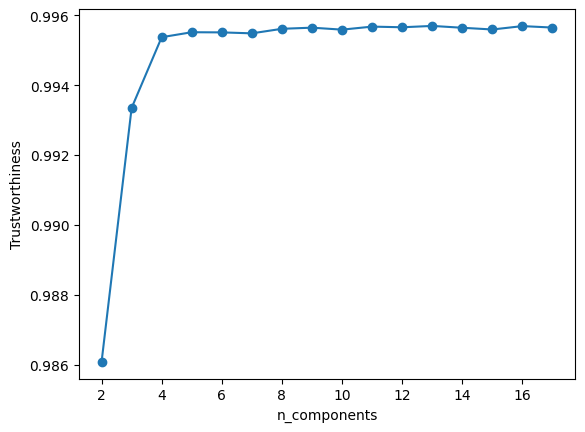

In [32]:
#Determine optimal number of components for UMAP using Trustworthiness
from sklearn.manifold import trustworthiness
scores = {}
for n in [x for x in range(2, 18)]:
    reducer = umap.UMAP(n_components=n, random_state=42)
    embedding = reducer.fit_transform(scaled_df)
    scores[n] = trustworthiness(scaled_df, embedding, n_neighbors=15)

plt.xlabel('n_components')
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.ylabel('Trustworthiness')

In [33]:
#convert scores to a dataframe
trust_scores_df = pd.DataFrame(list(scores.items()), columns=['n_components', 'Trustworthiness'])
trust_scores_df.sort_values(by='Trustworthiness', ascending=False, ignore_index=True)

,n_components,Trustworthiness
0,13,0.995695
1,16,0.995690
2,11,0.995675
3,12,0.995657
4,17,0.995648
5,9,0.995645
6,14,0.995643
7,8,0.995613
8,15,0.995593
9,10,0.995589


While the maximum score is for 13 components, the scores are all close together at around 0.996. Thus, 8 components are selected for UMAP. For the results of PCA, 8 components are needed to reach the 90% threshold for explained variance, 8 components are to be used. 

In [34]:
index = ['Baseline: K-means', 'Baseline: DBSCAN', 
         'UMAP to K-Means', 'UMAP to DBSCAN', 
           'PCA to K-Means', 'PCA to DBSCAN', ]
columns = ['K','Inertia', 'Calinski-Harabasz', 'Davies-Bouldin', 'Silhouette Score', '%Outlers (for DBSCAN)']

clustering_df = pd.DataFrame(np.nan, index=index, columns=columns)
clustering_df

,K,Inertia,Calinski-Harabasz,Davies-Bouldin,Silhouette Score,%Outlers (for DBSCAN)
Baseline: K-means,NaN,NaN,NaN,NaN,NaN,NaN
Baseline: DBSCAN,NaN,NaN,NaN,NaN,NaN,NaN
UMAP to K-Means,NaN,NaN,NaN,NaN,NaN,NaN
UMAP to DBSCAN,NaN,NaN,NaN,NaN,NaN,NaN
PCA to K-Means,NaN,NaN,NaN,NaN,NaN,NaN
PCA to DBSCAN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
def test_kmeans_k_values(X, k_range=range(2, 18)):
    """
    Test k-means clustering for a range of k values and evaluate multiple metrics.
    
    Parameters:
    -----------
    X : array-like, shape (n_samples, n_features)
        The input data to cluster
    k_range : range
        Range of k values to test (default: range(2, 18) for k=2 to 17)
    
    Returns:
    --------
    results_df : pandas.DataFrame
        DataFrame containing all metrics for each k value
    """
    
    # Initialize lists to store results
    inertias = []
    silhouette_scores = []
    calinski_scores = []
    davies_bouldin_scores = []
    
    # Store fitted models for potential further analysis
    models = {}
    
    # Test each k value
    for k in k_range:
        print(f"Testing k={k}...")
        
        # Create and fit KMeans model
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        
        # Store model
        models[k] = kmeans
        
        # Calculate metrics
        inertia = kmeans.inertia_
        sil_score = silhouette_score(X, labels)
        cal_score = calinski_harabasz_score(X, labels)
        dav_score = davies_bouldin_score(X, labels)
        
        # Append to lists
        inertias.append(inertia)
        silhouette_scores.append(sil_score)
        calinski_scores.append(cal_score)
        davies_bouldin_scores.append(dav_score)
        
        print(f"  Inertia: {inertia:.2f}")
        print(f"  Silhouette: {sil_score:.4f}")
        print(f"  Calinski-Harabasz: {cal_score:.2f}")
        print(f"  Davies-Bouldin: {dav_score:.4f}")
        print()
    
    # Create results DataFrame
    results_df = pd.DataFrame({
        'k': list(k_range),
        'Inertia': inertias,
        'Silhouette_Score': silhouette_scores,
        'Calinski_Harabasz': calinski_scores,
        'Davies_Bouldin': davies_bouldin_scores
    })
    
    # Find optimal k for each metric
    optimal_k = {}
    
    # Elbow method: find where the improvement drops significantly
    inertia_diffs = np.diff(inertias)
    if len(inertia_diffs) > 0:
        # Find the point of maximum curvature (knee)
        optimal_elbow_k = find_elbow_point(inertias)
        optimal_k['Elbow'] = optimal_elbow_k
    
    # Silhouette: higher is better
    optimal_k['Silhouette'] = k_range[np.argmax(silhouette_scores)]
    
    # Calinski-Harabasz: higher is better
    optimal_k['Calinski-Harabasz'] = k_range[np.argmax(calinski_scores)]
    
    # Davies-Bouldin: lower is better
    optimal_k['Davies-Bouldin'] = k_range[np.argmin(davies_bouldin_scores)]
    
    return results_df, models, optimal_k

def find_elbow_point(inertias):
    """
    Find the elbow point using the method of maximum curvature.
    """
    if len(inertias) < 3:
        return 2
    
    # Calculate the derivative (first differences)
    derivatives = np.diff(inertias)
    
    # Find where the derivative changes most (knee point)
    # Use the point of maximum second derivative magnitude
    second_derivatives = np.diff(derivatives)
    
    if len(second_derivatives) == 0:
        return 2
    
    # Add 2 to account for index offset (k starts at 2)
    elbow_idx = np.argmax(np.abs(second_derivatives)) + 1
    elbow_k = elbow_idx + 2  # because we start at k=2
    
    return elbow_k

def plot_metrics_results(results_df, save_path=None, figsize=(15, 10)):
    """
    Create visualization plots for all clustering metrics.
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    # Set style
    sns.set_palette("husl")
    
    # 1. Elbow Method (Inertia)
    ax1 = axes[0, 0]
    ax1.plot(results_df['k'], results_df['Inertia'], 'o-', linewidth=2, markersize=8, color='blue', alpha=0.8)
    ax1.set_xlabel('k (Number of Clusters)', fontsize=12)
    ax1.set_ylabel('Inertia', fontsize=12)
    ax1.set_title('Elbow Method - Inertia vs k', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Add annotation for elbow point
    if 'Elbow' in results_df.columns:
        elbow_k = results_df['k'][np.argmin(np.abs(np.diff(results_df['Inertia'])))]
        ax1.axvline(x=elbow_k, linestyle='--', color='red', alpha=0.7, linewidth=1.5, label=f'Elbow point (k={elbow_k})')
        ax1.legend()
    
    # 2. Silhouette Score
    ax2 = axes[0, 1]
    ax2.plot(results_df['k'], results_df['Silhouette_Score'], 'o-', linewidth=2, markersize=8, color='green', alpha=0.8)
    best_k_sil = results_df.loc[results_df['Silhouette_Score'].idxmax()]
    ax2.plot(best_k_sil['k'], best_k_sil['Silhouette_Score'], 'r*', markersize=15, label=f'Best k={int(best_k_sil["k"])}')
    ax2.set_xlabel('k (Number of Clusters)', fontsize=12)
    ax2.set_ylabel('Silhouette Score', fontsize=12)
    ax2.set_title('Silhouette Score vs k', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # 3. Calinski-Harabasz Score
    ax3 = axes[1, 0]
    ax3.plot(results_df['k'], results_df['Calinski_Harabasz'], 'o-', linewidth=2, markersize=8, color='orange', alpha=0.8)
    best_k_ch = results_df.loc[results_df['Calinski_Harabasz'].idxmax()]
    ax3.plot(best_k_ch['k'], best_k_ch['Calinski_Harabasz'], 'r*', markersize=15, label=f'Best k={int(best_k_ch["k"])}')
    ax3.set_xlabel('k (Number of Clusters)', fontsize=12)
    ax3.set_ylabel('Calinski-Harabasz Score', fontsize=12)
    ax3.set_title('Calinski-Harabasz Index vs k', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # 4. Davies-Bouldin Index
    ax4 = axes[1, 1]
    ax4.plot(results_df['k'], results_df['Davies_Bouldin'], 'o-', linewidth=2, markersize=8, color='purple', alpha=0.8)
    best_k_db = results_df.loc[results_df['Davies_Bouldin'].idxmin()]
    ax4.plot(best_k_db['k'], best_k_db['Davies_Bouldin'], 'r*', markersize=15, label=f'Best k={int(best_k_db["k"])}')
    ax4.set_xlabel('k (Number of Clusters)', fontsize=12)
    ax4.set_ylabel('Davies-Bouldin Index', fontsize=12)
    ax4.set_title('Davies-Bouldin Index vs k', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
    
    plt.show()
    return fig

def create_summary_table(results_df, optimal_k):
    """
    Create a summary table with optimal k values.
    """
    print("\n" + "="*60)
    print("SUMMARY OF OPTIMAL K VALUES")
    print("="*60)
    print(f"{'Metric':<25} {'Optimal k':^10} {'Best Value':^20}")
    print("-"*60)
    
    for metric, k in optimal_k.items():
        if metric == 'Elbow':
            value = results_df.loc[results_df['k'] == k, 'Inertia'].values[0]
            print(f"{metric:<25} {k:^10} {value:^20.2f}")
        elif metric == 'Silhouette':
            value = results_df.loc[results_df['k'] == k, 'Silhouette_Score'].values[0]
            print(f"{metric:<25} {k:^10} {value:^20.4f}")
        elif metric == 'Calinski-Harabasz':
            value = results_df.loc[results_df['k'] == k, 'Calinski_Harabasz'].values[0]
            print(f"{metric:<25} {k:^10} {value:^20.2f}")
        elif metric == 'Davies-Bouldin':
            value = results_df.loc[results_df['k'] == k, 'Davies_Bouldin'].values[0]
            print(f"{metric:<25} {k:^10} {value:^20.4f}")
    
    print("-"*60)
    
    # Find consensus optimal k
    from collections import Counter
    k_values = [int(v) for v in optimal_k.values()]
    k_counter = Counter(k_values)
    if k_counter:
        consensus_k = k_counter.most_common(1)[0]
        print(f"\nMost frequent optimal k: {consensus_k[0]} (appears {consensus_k[1]} times)")
    
    return None

2026/08/29 21:14:12 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '844c8b7668154e0ebcf444b136df08e2', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


Testing k=2...


2026/08/29 21:14:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:14:16 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:14:17 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '68386b8b0a944b83becba5b66cfb939a', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


  Inertia: 112340.01
  Silhouette: 0.2592
  Calinski-Harabasz: 3169.20
  Davies-Bouldin: 1.4702

Testing k=3...


2026/08/29 21:14:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:14:22 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:14:23 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'ceb6d1c4376941e3887aa7027c258ea1', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


...

  Inertia: 48396.94
  Silhouette: 0.1994
  Calinski-Harabasz: 1367.82
  Davies-Bouldin: 1.4482

Testing k=16...


2026/08/29 21:15:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:15:32 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:15:33 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '4fb154dafb854fd7bc60ed632a9a947b', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


  Inertia: 47386.38
  Silhouette: 0.1876
  Calinski-Harabasz: 1316.42
  Davies-Bouldin: 1.5190

Testing k=17...


2026/08/29 21:15:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:15:37 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


  Inertia: 45743.01
  Silhouette: 0.1934
  Calinski-Harabasz: 1298.39
  Davies-Bouldin: 1.5150



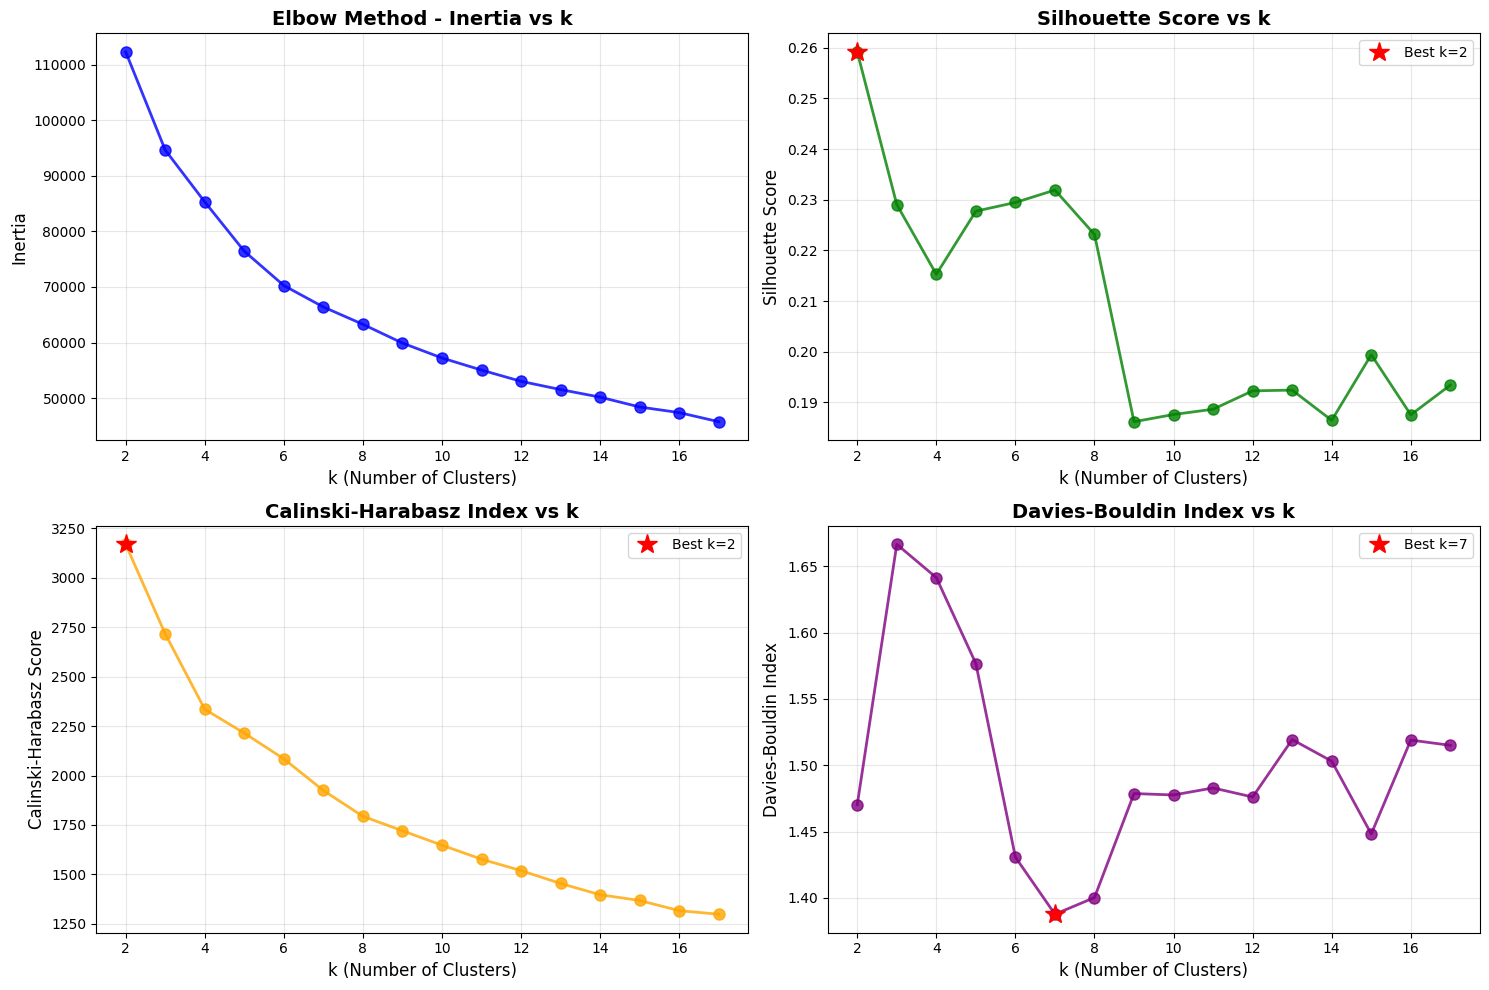


SUMMARY OF OPTIMAL K VALUES
Metric                    Optimal k       Best Value     
------------------------------------------------------------
Elbow                         3            94653.26      
Silhouette                    2             0.2592       
Calinski-Harabasz             2            3169.20       
Davies-Bouldin                7             1.3877       
------------------------------------------------------------

Most frequent optimal k: 2 (appears 2 times)


In [36]:
#Baseline
results_df, models, optimal_k = test_kmeans_k_values(scaled_df, k_range=range(2, 18))

# Create visualizations
plot_metrics_results(results_df)

# Create summary
create_summary_table(results_df, optimal_k)

Ignorning the AI summary table, the best K for the data without dimensionality reduction is K=7 due to having a slightly higher (relative to the others) Silhouette Score, Davies-Bouldin Index closesr to zero than its adjacent values and its Calinksi-Harabasz Index is higher than all K>7. Selecting between k=6, 7 or 8 is close but k=7 is the most "balanced".  

In [37]:
#baseline
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
labels = kmeans.fit_predict(scaled_df)


# Calculate metrics
inertia = kmeans.inertia_
sil_score = silhouette_score(scaled_df, labels)
cal_score = calinski_harabasz_score(scaled_df, labels)
dav_score = davies_bouldin_score(scaled_df, labels)

print(f"Inertia: {inertia:.2f}")
print(f"Silhouette Score: {sil_score:.4f}")
print(f"Calinkski-Harabasz Index: {cal_score:.2f}")
print(f"davies_bouldin_score: {dav_score:.2f}")

clustering_df.loc['Baseline: K-means', 'K'] = 7
clustering_df.loc['Baseline: K-means', 'Inertia'] = inertia
clustering_df.loc['Baseline: K-means', 'Silhouette Score'] = sil_score
clustering_df.loc['Baseline: K-means', 'Calinski-Harabasz'] = cal_score
clustering_df.loc['Baseline: K-means', 'Davies-Bouldin'] = dav_score

clustering_df

2026/08/29 21:15:39 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9f6d2054655e43aeb1d76739b829f824', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:15:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:15:43 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


Inertia: 66401.71
Silhouette Score: 0.2319
Calinkski-Harabasz Index: 1924.17
davies_bouldin_score: 1.39


,K,Inertia,Calinski-Harabasz,Davies-Bouldin,Silhouette Score,%Outlers (for DBSCAN)
Baseline: K-means,7.0,66401.707403,1924.170448,1.387658,0.231918,NaN
Baseline: DBSCAN,NaN,NaN,NaN,NaN,NaN,NaN
UMAP to K-Means,NaN,NaN,NaN,NaN,NaN,NaN
UMAP to DBSCAN,NaN,NaN,NaN,NaN,NaN,NaN
PCA to K-Means,NaN,NaN,NaN,NaN,NaN,NaN
PCA to DBSCAN,NaN,NaN,NaN,NaN,NaN,NaN


2026/08/29 21:15:44 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e6d63f6a00304213950b9e90cdc03ddb', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:15:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:15:45 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:15:48 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model traini

Testing k=2...


2026/08/29 21:15:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:15:52 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:15:54 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '98db6d7cd5e041afa7c6a608215b16b1', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


  Inertia: 100548.76
  Silhouette: 0.2800
  Calinski-Harabasz: 3538.56
  Davies-Bouldin: 1.3808

Testing k=3...


2026/08/29 21:15:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:15:58 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:16:00 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'cf9f37d6dad94134a3d8c59dab53a445', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


...

  Inertia: 38337.64
  Silhouette: 0.2168
  Calinski-Harabasz: 1697.46
  Davies-Bouldin: 1.3748

Testing k=16...


2026/08/29 21:17:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:17:10 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:17:12 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '294ccc7e50e94ca4a27092dee86a1ba9', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


  Inertia: 37235.75
  Silhouette: 0.2277
  Calinski-Harabasz: 1648.62
  Davies-Bouldin: 1.3593

Testing k=17...


2026/08/29 21:17:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:17:15 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


  Inertia: 36099.90
  Silhouette: 0.2206
  Calinski-Harabasz: 1611.60
  Davies-Bouldin: 1.3573



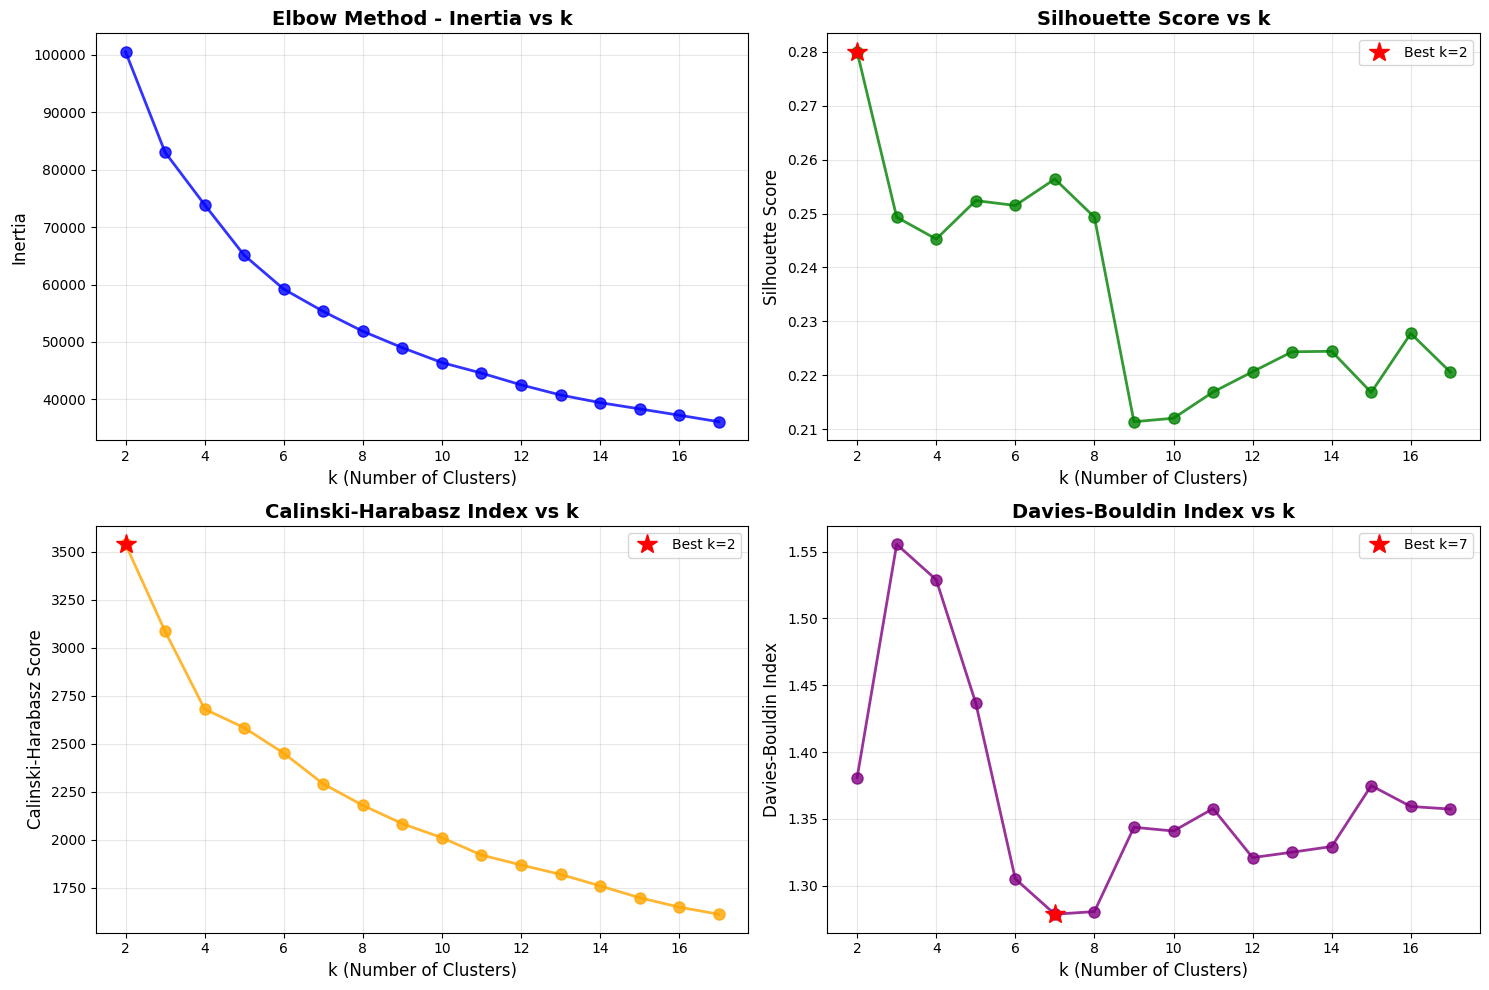

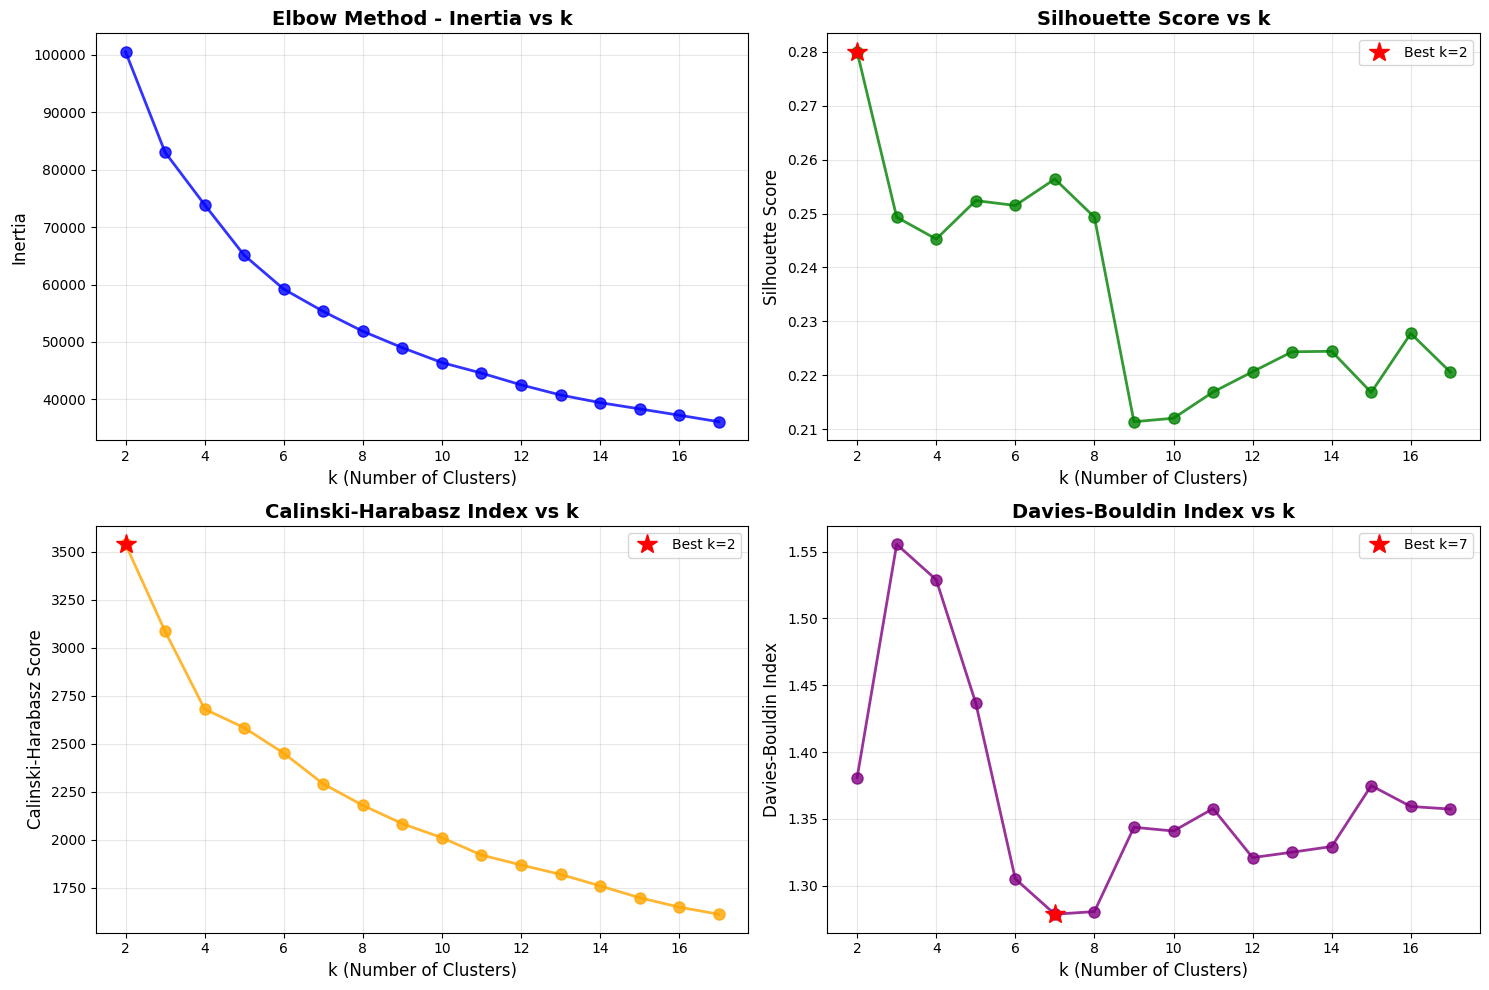

In [38]:
#PCA data
pca = PCA(n_components=8, random_state=42)
transformed = pca.fit_transform(scaled_df)
df_pca = pd.DataFrame(transformed)
results_df, models, optimal_k = test_kmeans_k_values(df_pca, k_range=range(2, 18))

# Create visualizations
plot_metrics_results(results_df)

In [39]:
#PCA to K-means 
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_pca)

# Calculate metrics
inertia = kmeans.inertia_
sil_score = silhouette_score(df_pca, labels)
cal_score = calinski_harabasz_score(df_pca, labels)
dav_score = davies_bouldin_score(df_pca, labels)

print(f"Inertia: {inertia:.2f}")
print(f"Silhouette Score: {sil_score:.4f}")
print(f"Calinkski-Harabasz Index: {cal_score:.2f}")
print(f"davies_bouldin_score: {dav_score:.2f}")

clustering_df.loc['PCA to K-Means', 'K'] = 7
clustering_df.loc['PCA to K-Means', 'Inertia'] = inertia
clustering_df.loc['PCA to K-Means', 'Silhouette Score'] = sil_score
clustering_df.loc['PCA to K-Means', 'Calinski-Harabasz'] = cal_score
clustering_df.loc['PCA to K-Means', 'Davies-Bouldin'] = dav_score

clustering_df

2026/08/29 21:17:18 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '31c545fa7a4a4a5cbbe0c06c49f56baa', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:17:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:17:22 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


Inertia: 55313.16
Silhouette Score: 0.2564
Calinkski-Harabasz Index: 2290.28
davies_bouldin_score: 1.28


,K,Inertia,Calinski-Harabasz,Davies-Bouldin,Silhouette Score,%Outlers (for DBSCAN)
Baseline: K-means,7.0,66401.707403,1924.170448,1.387658,0.231918,NaN
Baseline: DBSCAN,NaN,NaN,NaN,NaN,NaN,NaN
UMAP to K-Means,NaN,NaN,NaN,NaN,NaN,NaN
UMAP to DBSCAN,NaN,NaN,NaN,NaN,NaN,NaN
PCA to K-Means,7.0,55313.159144,2290.283310,1.278610,0.256406,NaN
PCA to DBSCAN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
def umap_reduce(X, min_dist=0.1, n_neighbors=15, n_components=2, random_state=42):
    """
    Reduce dimensionality of data using UMAP.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Input data to reduce.
    min_dist : float, default=0.1
        Minimum distance between points in the low-dimensional embedding.
    n_neighbors : int, default=15
        Number of local neighbors used to build the manifold structure.
    n_components : int, default=2
        Dimension of the reduced space.
    random_state : int, default=42
        Seed for reproducibility.

    Returns
    -------
    X_embedded : ndarray of shape (n_samples, n_components)
        The reduced-dimensional representation.
    reducer : umap.UMAP
        The fitted UMAP object (for transforming new data later).
    """
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        random_state=random_state,
    )
    X_embedded = reducer.fit_transform(X)
    return X_embedded, reducer

For the PCA data results, its important to note that the PCA data has 8 features, and thus picking K=7 would lead ad to overfitting. The second best would be k=5 from the metrics. Therefore, K=5 is selected for PCA to K-means

2026/08/29 21:17:34 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'bc459154a2a740569fb21ae594933591', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:17:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Testing k=2...


2026/08/29 21:17:38 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:17:39 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '089dcb9323e948f5ac88053de9f39ba2', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:17:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Inertia: 283855.22
  Silhouette: 0.5446
  Calinski-Harabasz: 9094.71
  Davies-Bouldin: 0.5660

Testing k=3...


2026/08/29 21:17:43 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:17:44 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '2d51a6a7669144188d10d2132c665860', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:17:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

  Inertia: 7889.15
  Silhouette: 0.4811
  Calinski-Harabasz: 45662.39
  Davies-Bouldin: 0.8476

Testing k=16...


2026/08/29 21:18:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:18:48 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:18:50 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '11a2c0151afb4020a236517588fb5d10', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


  Inertia: 7604.83
  Silhouette: 0.4675
  Calinski-Harabasz: 44230.43
  Davies-Bouldin: 0.9010

Testing k=17...


2026/08/29 21:18:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:18:54 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


  Inertia: 6909.17
  Silhouette: 0.4962
  Calinski-Harabasz: 45690.86
  Davies-Bouldin: 0.7466



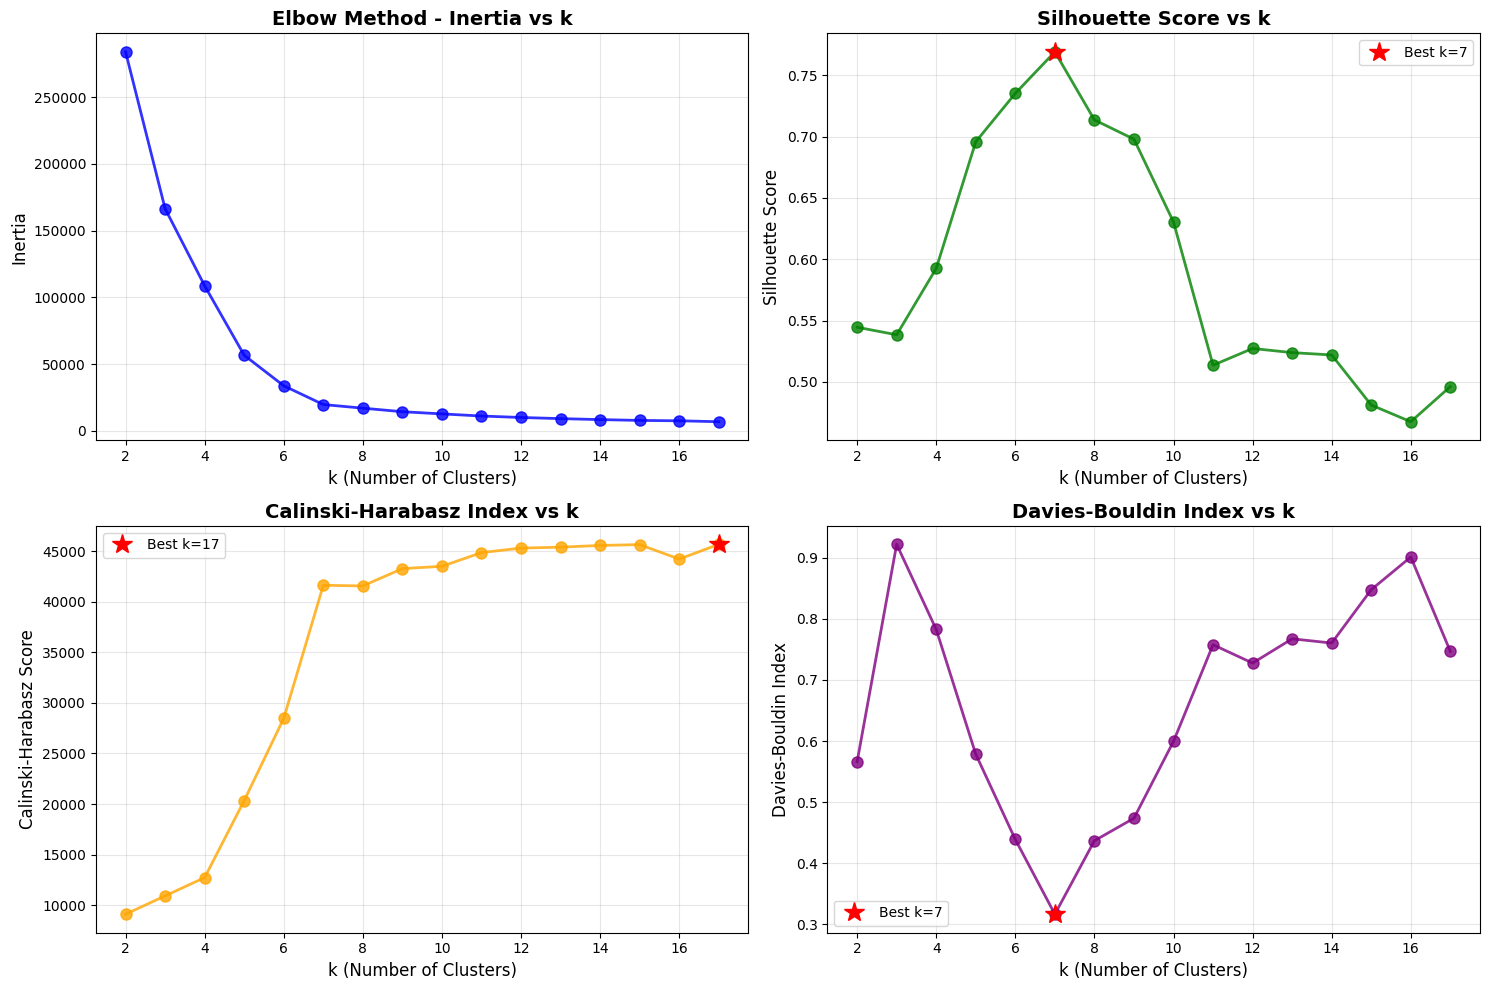

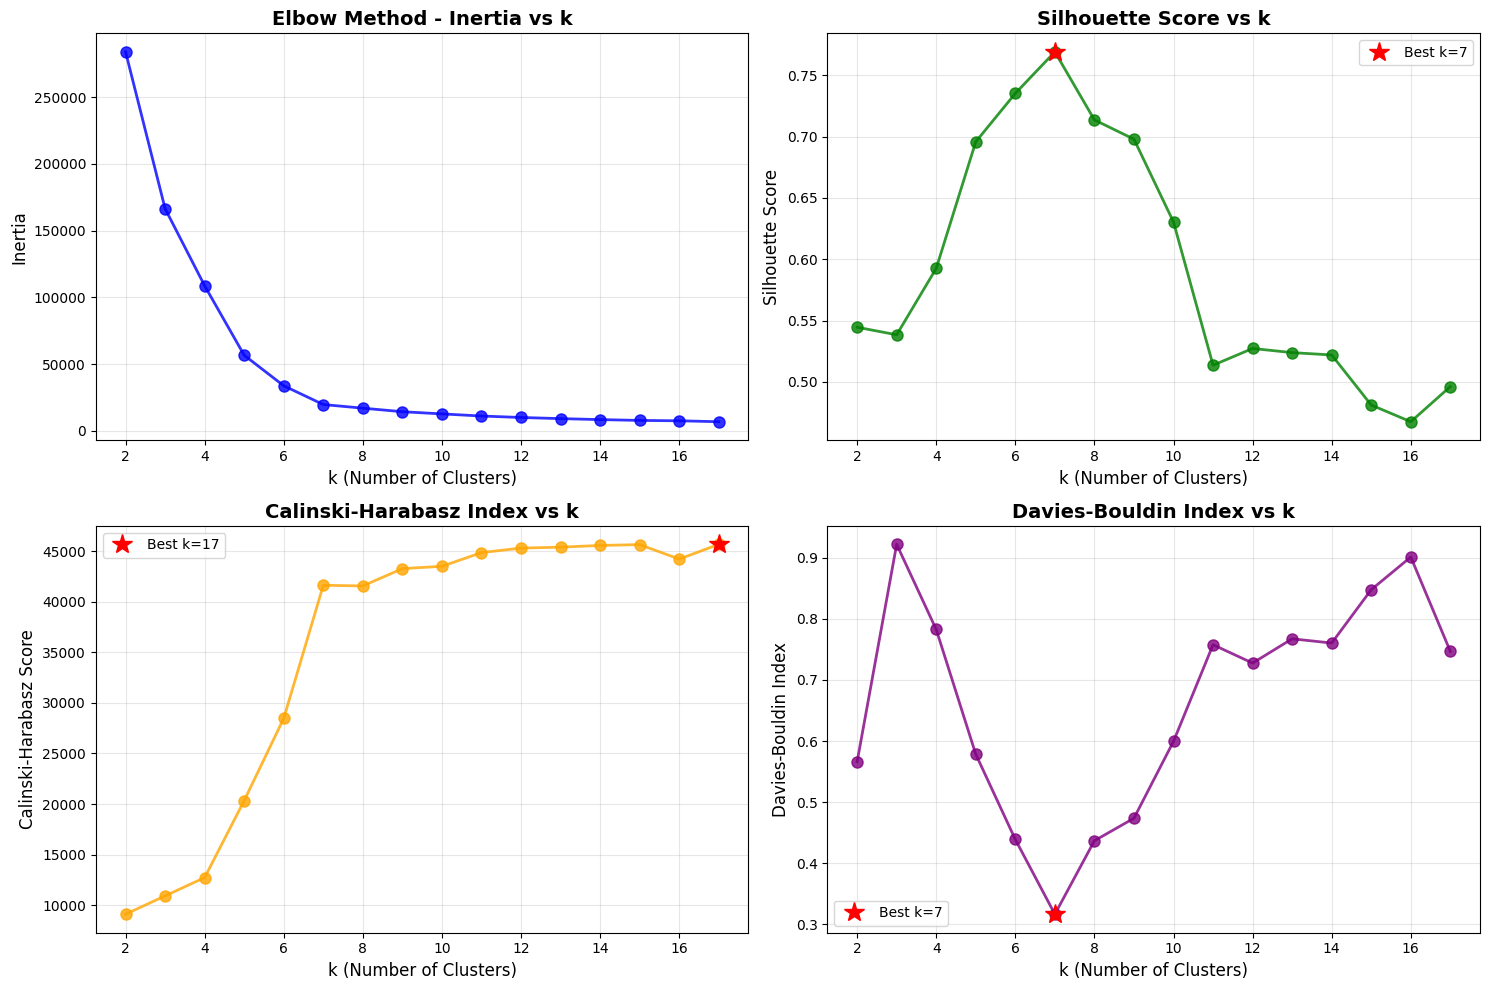

In [41]:
reduced_df = umap_reduce(scaled_df,  n_components=8)
results_df, models, optimal_k = test_kmeans_k_values(reduced_df[0])

# Create visualizations
plot_metrics_results(results_df)

In [42]:
#UMAP to K-means 
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
labels = kmeans.fit_predict(reduced_df[0])

# Calculate metrics
inertia = kmeans.inertia_
sil_score = silhouette_score(reduced_df[0], labels)
cal_score = calinski_harabasz_score(reduced_df[0], labels)
dav_score = davies_bouldin_score(reduced_df[0], labels)

print(f"Inertia: {inertia:.2f}")
print(f"Silhouette Score: {sil_score:.4f}")
print(f"Calinkski-Harabasz Index: {cal_score:.2f}")
print(f"davies_bouldin_score: {dav_score:.2f}")

clustering_df.loc['UMAP to K-Means', 'K'] = 7
clustering_df.loc['UMAP to K-Means', 'Inertia'] = inertia
clustering_df.loc['UMAP to K-Means', 'Silhouette Score'] = sil_score
clustering_df.loc['UMAP to K-Means', 'Calinski-Harabasz'] = cal_score
clustering_df.loc['UMAP to K-Means', 'Davies-Bouldin'] = dav_score

clustering_df

2026/08/29 21:18:55 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '1c2e30fb76084289bf37f02bf8da0fc1', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:18:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:18:59 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


Inertia: 19778.55
Silhouette Score: 0.7692
Calinkski-Harabasz Index: 41640.31
davies_bouldin_score: 0.32


,K,Inertia,Calinski-Harabasz,Davies-Bouldin,Silhouette Score,%Outlers (for DBSCAN)
Baseline: K-means,7.0,66401.707403,1924.170448,1.387658,0.231918,NaN
Baseline: DBSCAN,NaN,NaN,NaN,NaN,NaN,NaN
UMAP to K-Means,7.0,19778.548828,41640.312500,0.316696,0.769160,NaN
UMAP to DBSCAN,NaN,NaN,NaN,NaN,NaN,NaN
PCA to K-Means,7.0,55313.159144,2290.283310,1.278610,0.256406,NaN
PCA to DBSCAN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
def test_dbscan_parameters(X, eps_values=None, min_samples_values=None, 
                          metric='euclidean', show_plots=True):
    """
    Test DBSCAN clustering for different parameter combinations and evaluate metrics.
    
    Parameters:
    -----------
    X : array-like, shape (n_samples, n_features)
        The input data to cluster
    eps_values : array-like, optional
        List of epsilon values to test. If None, auto-generate based on distance metrics
    min_samples_values : array-like, optional
        List of min_samples values to test. If None, use [2, 3, 5, 10]
    metric : str, optional
        Distance metric to use (default: 'euclidean')
    show_plots : bool, optional
        Whether to show plots (default: True)
    
    Returns:
    --------
    results_df : pandas.DataFrame
        DataFrame containing all metrics for each parameter combination
    best_params : dict
        Best parameters for each metric
    X : array-like
        The input data (standardized)
    """
    
    # Initialize default parameters if not provided
    if eps_values is None or min_samples_values is None:
        # Auto-generate eps values based on k-distance plot
        eps_values, min_samples_values = suggest_dbscan_params(X, metric=metric)
    
    # Initialize lists to store results
    results = []
    models = {}
    
    # Test each combination of parameters
    for eps in eps_values:
        for min_samples in min_samples_values:
            print(f"Testing eps={eps:.3f}, min_samples={min_samples}...")
            
            # Create and fit DBSCAN model
            dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric, n_jobs=-1)
            labels = dbscan.fit_predict(X)
            
            # Calculate metrics
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            n_samples = len(X)
            percentage_noise = (n_noise / n_samples) * 100
            
            # Store model
            models[(eps, min_samples)] = dbscan
            
            # Only calculate metrics if we have more than 1 cluster
            if n_clusters > 1:
                # Filter out noise points for metrics calculation
                mask = labels != -1
                if len(np.unique(labels[mask])) > 1:
                    sil_score = silhouette_score(X[mask], labels[mask])
                    cal_score = calinski_harabasz_score(X[mask], labels[mask])
                    dav_score = davies_bouldin_score(X[mask], labels[mask])
                else:
                    sil_score = np.nan
                    cal_score = np.nan
                    dav_score = np.nan
            else:
                sil_score = np.nan
                cal_score = np.nan
                dav_score = np.nan
            
            # Store results
            results.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_outliers': n_noise,
                'percentage_outliers': percentage_noise,
                'percentage_clustered': 100 - percentage_noise,
                'silhouette_score': sil_score,
                'calinski_harabasz': cal_score,
                'davies_bouldin': dav_score,
                'model': dbscan
            })
            
            print(f"  Clusters: {n_clusters}, Outliers: {n_noise} ({percentage_noise:.1f}%)")
            if not np.isnan(sil_score):
                print(f"  Silhouette: {sil_score:.4f}, CH: {cal_score:.2f}, DB: {dav_score:.4f}")
            print()
    
    # Create results DataFrame (excluding model object)
    results_df = pd.DataFrame([{k: v for k, v in d.items() if k != 'model'} for d in results])
    
    # Find best parameters for each metric
    best_params = find_best_dbscan_params(results_df)
    
    # Create visualizations
    if show_plots:
        fig = plot_dbscan_results(results_df, best_params, X, models)
    
    # Print summary
    print_dbscan_summary(results_df, best_params)
    
    return results_df, best_params, models

def suggest_dbscan_params(X, metric='euclidean', k_min=2, k_max=20):
    """
    Suggest DBSCAN parameters using k-distance plot.
    """
    # Calculate k-distances
    neighbors = NearestNeighbors(n_neighbors=k_max, metric=metric)
    neighbors.fit(X)
    distances, indices = neighbors.kneighbors(X)
    
    # Sort distances for the k-th nearest neighbor
    k_distances = np.sort(distances[:, k_min-1])
    
    # Find the elbow point in the k-distance plot
    kneedle = KneeLocator(range(len(k_distances)), k_distances, curve='convex', direction='increasing')
    
    if kneedle.knee is not None:
        suggested_eps = k_distances[kneedle.knee]
    else:
        # Fallback: use percentile-based approach
        suggested_eps = np.percentile(k_distances, 95)
    
    # Generate eps values around the suggested point
    eps_values = np.linspace(suggested_eps * 0.5, suggested_eps * 2, 5)
    
    # Generate min_samples values
    min_samples_values = [2, 3, 5, 10, 15, 20]
    
    return eps_values, min_samples_values

def find_best_dbscan_params(results_df):
    """
    Find the best DBSCAN parameters for each metric.
    """
    best_params = {}
    
    # Filter only valid results (with metrics)
    valid_mask = results_df['n_clusters'] > 1
    
    # Best by silhouette score (higher is better)
    if valid_mask.any() and not results_df.loc[valid_mask, 'silhouette_score'].isna().all():
        best_idx = results_df.loc[valid_mask, 'silhouette_score'].idxmax()
        best_params['Silhouette'] = (results_df.loc[best_idx, 'eps'], 
                                    int(results_df.loc[best_idx, 'min_samples']),
                                    results_df.loc[best_idx, 'silhouette_score'])
    
    # Best by Calinski-Harabasz (higher is better)
    if valid_mask.any() and not results_df.loc[valid_mask, 'calinski_harabasz'].isna().all():
        best_idx = results_df.loc[valid_mask, 'calinski_harabasz'].idxmax()
        best_params['Calinski-Harabasz'] = (results_df.loc[best_idx, 'eps'], 
                                           int(results_df.loc[best_idx, 'min_samples']),
                                           results_df.loc[best_idx, 'calinski_harabasz'])
    
    # Best by Davies-Bouldin (lower is better)
    if valid_mask.any() and not results_df.loc[valid_mask, 'davies_bouldin'].isna().all():
        best_idx = results_df.loc[valid_mask, 'davies_bouldin'].idxmin()
        best_params['Davies-Bouldin'] = (results_df.loc[best_idx, 'eps'], 
                                        int(results_df.loc[best_idx, 'min_samples']),
                                        results_df.loc[best_idx, 'davies_bouldin'])
    
    # Best by outlier percentage (reasonable amount, not too high or low)
    # Target: 5-30% outliers for meaningful detection
    reasonable_outliers = results_df[(results_df['percentage_outliers'] >= 5) & 
                                   (results_df['percentage_outliers'] <= 30)]
    if not reasonable_outliers.empty:
        best_idx = reasonable_outliers['percentage_outliers'].idxmin()
        best_params['Reasonable Outliers'] = (results_df.loc[best_idx, 'eps'], 
                                            int(results_df.loc[best_idx, 'min_samples']),
                                            results_df.loc[best_idx, 'percentage_outliers'])
    
    return best_params

def plot_dbscan_results(results_df, best_params, X, models, save_path=None):
    """
    Create comprehensive visualizations for DBSCAN results.
    """
    fig = plt.figure(figsize=(20, 16))
    
    # Subplot 1: Cluster count heatmap
    ax1 = plt.subplot(3, 3, 1)
    pivot_clusters = results_df.pivot_table(values='n_clusters', 
                                           index='min_samples', 
                                           columns='eps', 
                                           aggfunc='mean')
    sns.heatmap(pivot_clusters, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax1, cbar_kws={'label': 'Number of Clusters'})
    ax1.set_title('Number of Clusters', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epsilon (eps)')
    ax1.set_ylabel('Min Samples')
    
    # Subplot 2: Outlier percentage heatmap
    ax2 = plt.subplot(3, 3, 2)
    pivot_outliers = results_df.pivot_table(values='percentage_outliers', 
                                           index='min_samples', 
                                           columns='eps', 
                                           aggfunc='mean')
    sns.heatmap(pivot_outliers, annot=True, fmt='.1f', cmap='Blues', ax=ax2, cbar_kws={'label': 'Outlier %'})
    ax2.set_title('Percentage of Outliers', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epsilon (eps)')
    ax2.set_ylabel('Min Samples')
    
    # Subplot 3: Silhouette score heatmap
    ax3 = plt.subplot(3, 3, 3)
    pivot_sil = results_df.pivot_table(values='silhouette_score', 
                                      index='min_samples', 
                                      columns='eps', 
                                      aggfunc='mean')
    sns.heatmap(pivot_sil, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax3, cbar_kws={'label': 'Silhouette Score'})
    ax3.set_title('Silhouette Score', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epsilon (eps)')
    ax3.set_ylabel('Min Samples')
    
    # Subplot 4: Percentage clustered vs eps (line plot for each min_samples)
    ax4 = plt.subplot(3, 3, 4)
    for ms in results_df['min_samples'].unique():
        subset = results_df[results_df['min_samples'] == ms]
        ax4.plot(subset['eps'], subset['percentage_clustered'], 'o-', 
                label=f'min_samples={ms}', markersize=6)
    ax4.set_xlabel('Epsilon (eps)', fontsize=12)
    ax4.set_ylabel('Percentage Clustered (%)', fontsize=12)
    ax4.set_title('Percentage of Points Clustered vs Epsilon', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    # Subplot 5: Number of clusters vs eps (line plot for each min_samples)
    ax5 = plt.subplot(3, 3, 5)
    for ms in results_df['min_samples'].unique():
        subset = results_df[results_df['min_samples'] == ms]
        ax5.plot(subset['eps'], subset['n_clusters'], 's-', 
                label=f'min_samples={ms}', markersize=6)
    ax5.set_xlabel('Epsilon (eps)', fontsize=12)
    ax5.set_ylabel('Number of Clusters', fontsize=12)
    ax5.set_title('Number of Clusters vs Epsilon', fontsize=14, fontweight='bold')
    ax5.grid(True, alpha=0.3)
    ax5.legend()
    
    # Subplot 6: Silhouette score vs eps (line plot for each min_samples)
    ax6 = plt.subplot(3, 3, 6)
    for ms in results_df['min_samples'].unique():
        subset = results_df[results_df['min_samples'] == ms]
        valid = ~subset['silhouette_score'].isna()
        ax6.plot(subset.loc[valid, 'eps'], subset.loc[valid, 'silhouette_score'], 'd-', 
                label=f'min_samples={ms}', markersize=6)
    ax6.set_xlabel('Epsilon (eps)', fontsize=12)
    ax6.set_ylabel('Silhouette Score', fontsize=12)
    ax6.set_title('Silhouette Score vs Epsilon', fontsize=14, fontweight='bold')
    ax6.grid(True, alpha=0.3)
    ax6.legend()
    
    # Subplot 7: 2D visualization with best parameters
    ax7 = plt.subplot(3, 3, 7)
    if len(best_params) > 0 and len(models) > 0:
        # Find the best parameters based on silhouette score
        best_key = None
        if 'Silhouette' in best_params:
            best_key = best_params['Silhouette'][:2]
        
        if best_key is not None and best_key in models:
            labels = models[best_key].fit_predict(X)
            
            # If data has more than 2 dimensions, use PCA for visualization
            if X.shape[1] > 2:
                from sklearn.decomposition import PCA
                pca = PCA(n_components=2)
                X_2d = pca.fit_transform(X)
            else:
                X_2d = X
            
            # Plot clusters
            unique_labels = np.unique(labels)
            colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))
            
            for i, (label, color) in enumerate(zip(unique_labels, colors)):
                if label == -1:
                    # Noise points
                    ax7.scatter(X_2d[labels == -1, 0], X_2d[labels == -1, 1], 
                              c='black', marker='x', s=50, label='Outliers', alpha=0.7)
                else:
                    ax7.scatter(X_2d[labels == label, 0], X_2d[labels == label, 1], 
                              c=[color], marker='o', s=30, alpha=0.7, label=f'Cluster {label}')
            
            ax7.set_xlabel('PC1' if X.shape[1] > 2 else 'Feature 1', fontsize=12)
            ax7.set_ylabel('PC2' if X.shape[1] > 2 else 'Feature 2', fontsize=12)
            ax7.set_title(f'DBSCAN Clustering (eps={best_key[0]:.3f}, min_samples={best_key[1]})', 
                        fontsize=14, fontweight='bold')
            ax7.legend(loc='best', fontsize=8)
            ax7.grid(True, alpha=0.3)
    
    # Subplot 8: Outlier count bar plot
    ax8 = plt.subplot(3, 3, 8)
    x_pos = np.arange(len(results_df))
    outlier_counts = results_df['n_outliers'].values
    bars = ax8.bar(x_pos, outlier_counts, color='red', alpha=0.7)
    ax8.set_xlabel('Parameter Combination', fontsize=12)
    ax8.set_ylabel('Number of Outliers', fontsize=12)
    ax8.set_title('Outlier Count for Each Parameter Set', fontsize=14, fontweight='bold')
    ax8.set_xticks(x_pos[::2])
    ax8.set_xticklabels([f"{results_df['eps'].iloc[i]:.2f},\n{results_df['min_samples'].iloc[i]}" 
                        for i in x_pos[::2]], rotation=45, fontsize=8)
    ax8.grid(True, alpha=0.3, axis='y')
    
    # Subplot 9: Best parameters summary text
    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('off')
    ax9.text(0.1, 0.9, 'BEST PARAMETERS', fontsize=16, fontweight='bold')
    
    y_pos = 0.7
    for metric, params in best_params.items():
        eps, ms, score = params
        ax9.text(0.1, y_pos, f'{metric}:\n  eps={eps:.3f}, min_samples={ms}\n  Score={score:.4f}', 
                fontsize=10, va='top')
        y_pos -= 0.2
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
    
    plt.show()
    return fig

def print_dbscan_summary(results_df, best_params):
    """
    Print a comprehensive summary of DBSCAN results.
    """
    print("\n" + "="*70)
    print("DBSCAN PARAMETER TESTING SUMMARY")
    print("="*70)
    
    # Overall statistics
    print("\nOVERALL STATISTICS:")
    print("-"*50)
    all_outliers = results_df.groupby(['eps', 'min_samples'])['n_outliers'].mean()
    print(f"Mean outliers across all tests: {all_outliers.mean():.2f}")
    print(f"Median outliers across all tests: {all_outliers.median():.2f}")
    print(f"Max outliers: {results_df['n_outliers'].max()}")
    print(f"Min outliers: {results_df['n_outliers'].min()}")
    
    # Best parameters for each metric
    print("\nBEST PARAMETERS BY METRIC:")
    print("-"*50)
    for metric, params in best_params.items():
        eps, ms, score = params
        print(f"{metric}:")
        print(f"  eps = {eps:.3f}, min_samples = {ms}")
        if metric == 'Silhouette' or metric == 'Calinski-Harabasz' or metric == 'Davies-Bouldin':
            print(f"  Score = {score:.4f}")
        else:
            print(f"  Outliers = {score:.1f}%")
    
    # Outlier analysis
    print("\nOUTLIER ANALYSIS:")
    print("-"*50)
    outlier_stats = results_df['percentage_outliers'].describe()
    print(f"Average outlier percentage: {outlier_stats['mean']:.2f}%")
    print(f"Min outlier percentage: {outlier_stats['min']:.2f}%")
    print(f"Max outlier percentage: {outlier_stats['max']:.2f}%")
    
    # Recommend parameters
    print("\nRECOMMENDATIONS:")
    print("-"*50)
    print("To choose the best parameters, consider:")
    print("1. Balance between cluster quality metrics and outlier detection")
    print("2. Domain knowledge about expected outlier proportion")
    print("3. The 'Reasonable Outliers' metric suggests parameters that detect")
    print("   a meaningful amount of outliers (5-30%) ")
    
    return None

def find_optimal_dbscan_parameters(X, target_outlier_percentage=10, 
                                  eps_range=None, min_samples_range=None):
    """
    Find DBSCAN parameters that achieve a target outlier percentage.
    """
    if eps_range is None:
        eps_range = np.linspace(0.1, 5, 20)
    if min_samples_range is None:
        min_samples_range = range(2, 21)
    
    best_result = None
    best_diff = float('inf')
    
    for eps in eps_range:
        for min_samples in min_samples_range:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
            labels = dbscan.fit_predict(X)
            
            n_outliers = list(labels).count(-1)
            outlier_pct = (n_outliers / len(X)) * 100
            
            diff = abs(outlier_pct - target_outlier_percentage)
            if diff < best_diff:
                best_diff = diff
                best_result = {
                    'eps': eps,
                    'min_samples': min_samples,
                    'outlier_pct': outlier_pct,
                    'n_clusters': len(set(labels)) - (1 if -1 in labels else 0),
                    'diff': diff
                }
    
    return best_result

2026/08/29 21:19:01 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '5e2c59faab0b4f72a1cfc668aecdb146', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:19:01 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:19:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:19:01 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:19:05 WARNI

Testing eps=1.213, min_samples=2...


2026/08/29 21:19:05 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:19:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:19:05 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:19:09 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:19:10 INFO mlflow.utils.autologging_ut

  Clusters: 179, Outliers: 1520 (17.0%)
  Silhouette: -0.3408, CH: 37.12, DB: 0.9694

Testing eps=1.213, min_samples=3...


2026/08/29 21:19:11 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:19:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:19:11 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:19:14 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:19:15 INFO mlflow.utils.autologging_ut

...

2026/08/29 21:21:26 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:21:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:21:26 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:21:30 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:21:30 INFO mlflow.utils.autologging_ut

  Clusters: 1, Outliers: 0 (0.0%)

Testing eps=4.854, min_samples=20...


2026/08/29 21:21:32 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:21:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:21:32 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:21:35 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


  Clusters: 1, Outliers: 0 (0.0%)



2026/08/29 21:21:36 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '8206f1cd05a041b69e1c3bf0b1fb4deb', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:21:36 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:21:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:21:36 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:21:40 WARNI

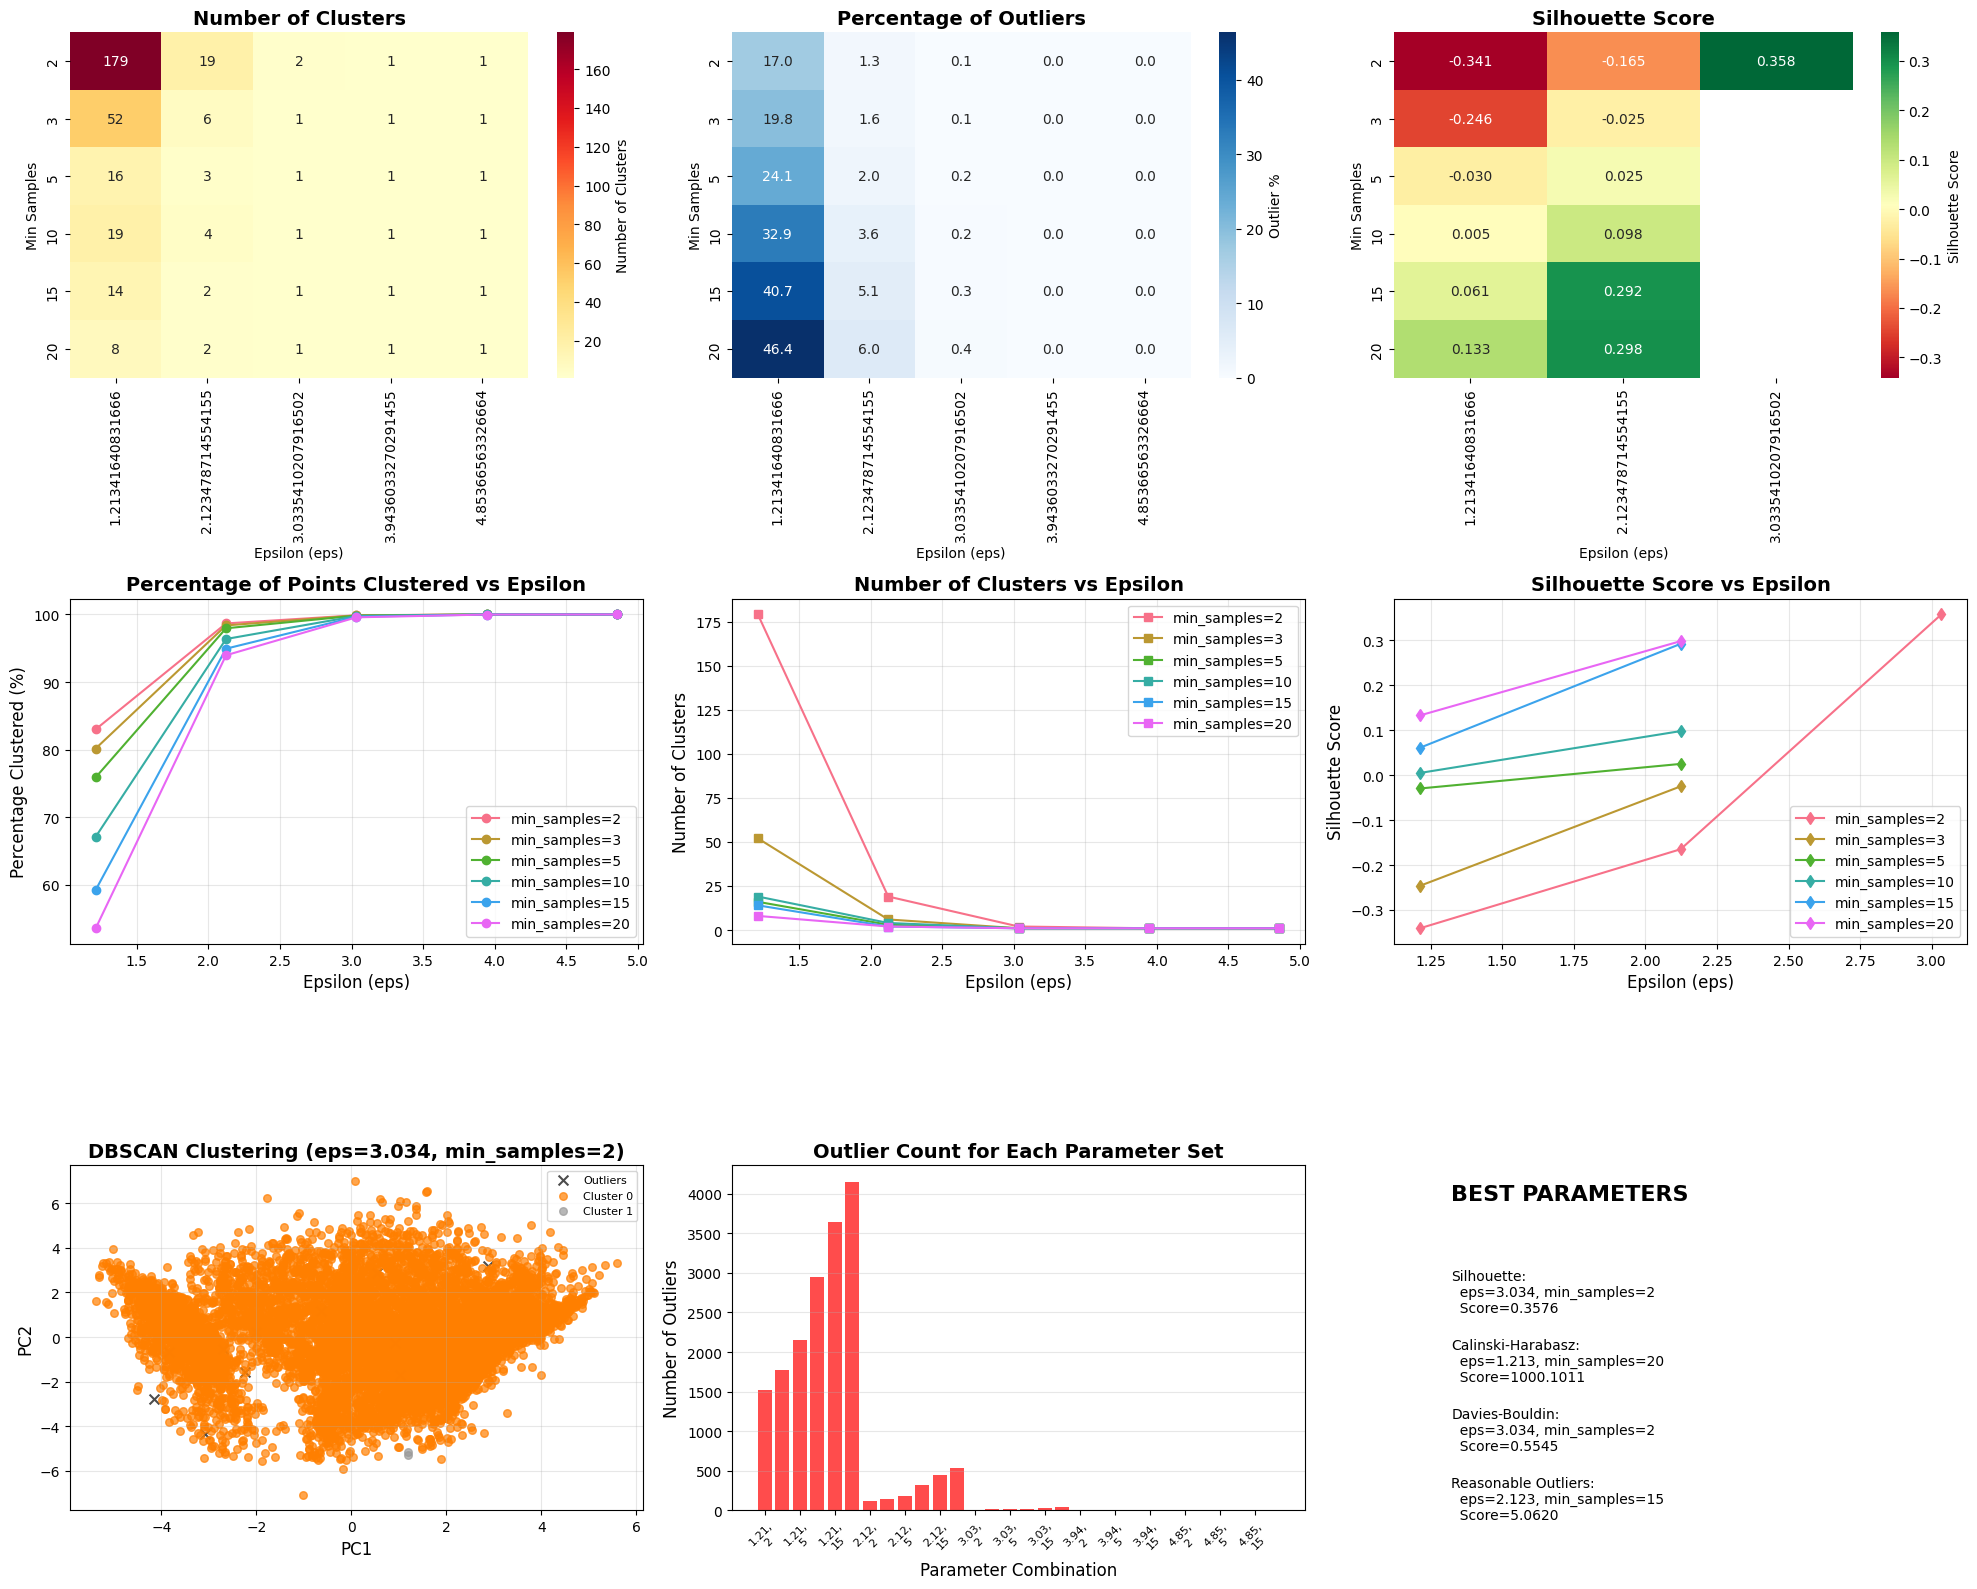


DBSCAN PARAMETER TESTING SUMMARY

OVERALL STATISTICS:
--------------------------------------------------
Mean outliers across all tests: 602.80
Median outliers across all tests: 18.00
Max outliers: 4153
Min outliers: 0

BEST PARAMETERS BY METRIC:
--------------------------------------------------
Silhouette:
  eps = 3.034, min_samples = 2
  Score = 0.3576
Calinski-Harabasz:
  eps = 1.213, min_samples = 20
  Score = 1000.1011
Davies-Bouldin:
  eps = 3.034, min_samples = 2
  Score = 0.5545
Reasonable Outliers:
  eps = 2.123, min_samples = 15
  Outliers = 5.1%

OUTLIER ANALYSIS:
--------------------------------------------------
Average outlier percentage: 6.74%
Min outlier percentage: 0.00%
Max outlier percentage: 46.41%

RECOMMENDATIONS:
--------------------------------------------------
To choose the best parameters, consider:
1. Balance between cluster quality metrics and outlier detection
2. Domain knowledge about expected outlier proportion
3. The 'Reasonable Outliers' metric sugge

In [44]:
results_df, best_params, models = test_dbscan_parameters(scaled_df)

hyperparameters to use: eps = 3.034, min_samples = 2

In [45]:
#dbscan: baseline
db = DBSCAN(eps=3.034, min_samples=2)
labels = db.fit_predict(scaled_df)

# Outliers/Noise points are automatically labeled as -1
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

db_sil_baseline = silhouette_score(scaled_df, labels)
db_cal_baseline = calinski_harabasz_score(scaled_df, labels)
db_dav_baseline = davies_bouldin_score(scaled_df, labels)

print(f"Estimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")
print(f"Percentage of noise points: {n_noise / len(scaled_df) * 100:.2f}%")
print(f"Silhouette Score: {db_sil_baseline:.4f}")
print(f"Calinkski-Harabasz Index: {db_cal_baseline:.2f}")
print(f"davies_bouldin_score: {db_dav_baseline}")

2026/08/29 21:21:45 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '839e7276805143cb8387db130c9d9463', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:21:45 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:21:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:21:46 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:21:49 WARNI

Estimated number of clusters: 2
Estimated number of noise points: 11
Percentage of noise points: 0.12%
Silhouette Score: 0.2611
Calinkski-Harabasz Index: 8.09
davies_bouldin_score: 1.9973508834757296


In [46]:
#Baseline: DBSCAN
clustering_df.loc['Baseline: DBSCAN', 'K'] = n_clusters
clustering_df.loc['Baseline: DBSCAN', 'Silhouette Score'] = db_sil_baseline
clustering_df.loc['Baseline: DBSCAN', 'Calinski-Harabasz'] = db_cal_baseline
clustering_df.loc['Baseline: DBSCAN', 'Davies-Bouldin'] = db_dav_baseline
clustering_df.loc['Baseline: DBSCAN', '%Outlers (for DBSCAN)'] = round(n_noise / len(scaled_df) * 100, 2) 

clustering_df

,K,Inertia,Calinski-Harabasz,Davies-Bouldin,Silhouette Score,%Outlers (for DBSCAN)
Baseline: K-means,7.0,66401.707403,1924.170448,1.387658,0.231918,NaN
Baseline: DBSCAN,2.0,NaN,8.087015,1.997351,0.261063,0.12
UMAP to K-Means,7.0,19778.548828,41640.312500,0.316696,0.769160,NaN
UMAP to DBSCAN,NaN,NaN,NaN,NaN,NaN,NaN
PCA to K-Means,7.0,55313.159144,2290.283310,1.278610,0.256406,NaN
PCA to DBSCAN,NaN,NaN,NaN,NaN,NaN,NaN


2026/08/29 21:21:51 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '11132a747a3d4f9bad9c9cfee0137af9', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:21:51 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:21:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:21:51 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:21:54 WARNI

Testing eps=0.988, min_samples=2...


2026/08/29 21:21:55 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:21:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:21:55 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:21:58 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:22:00 INFO mlflow.utils.autologging_ut

  Clusters: 180, Outliers: 1219 (13.6%)
  Silhouette: -0.4136, CH: 27.96, DB: 0.9604

Testing eps=0.988, min_samples=3...


2026/08/29 21:22:00 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:22:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:22:00 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:22:04 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:22:05 INFO mlflow.utils.autologging_ut

...

2026/08/29 21:24:14 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:24:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:24:14 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:24:18 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:24:18 INFO mlflow.utils.autologging_ut

  Clusters: 1, Outliers: 0 (0.0%)

Testing eps=3.952, min_samples=20...


2026/08/29 21:24:19 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:24:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:24:19 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:24:23 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


  Clusters: 1, Outliers: 0 (0.0%)



2026/08/29 21:24:23 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '88c188e992a04dee9ff2d6a810f4c05e', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:24:24 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:24:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:24:24 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:24:28 WARNI

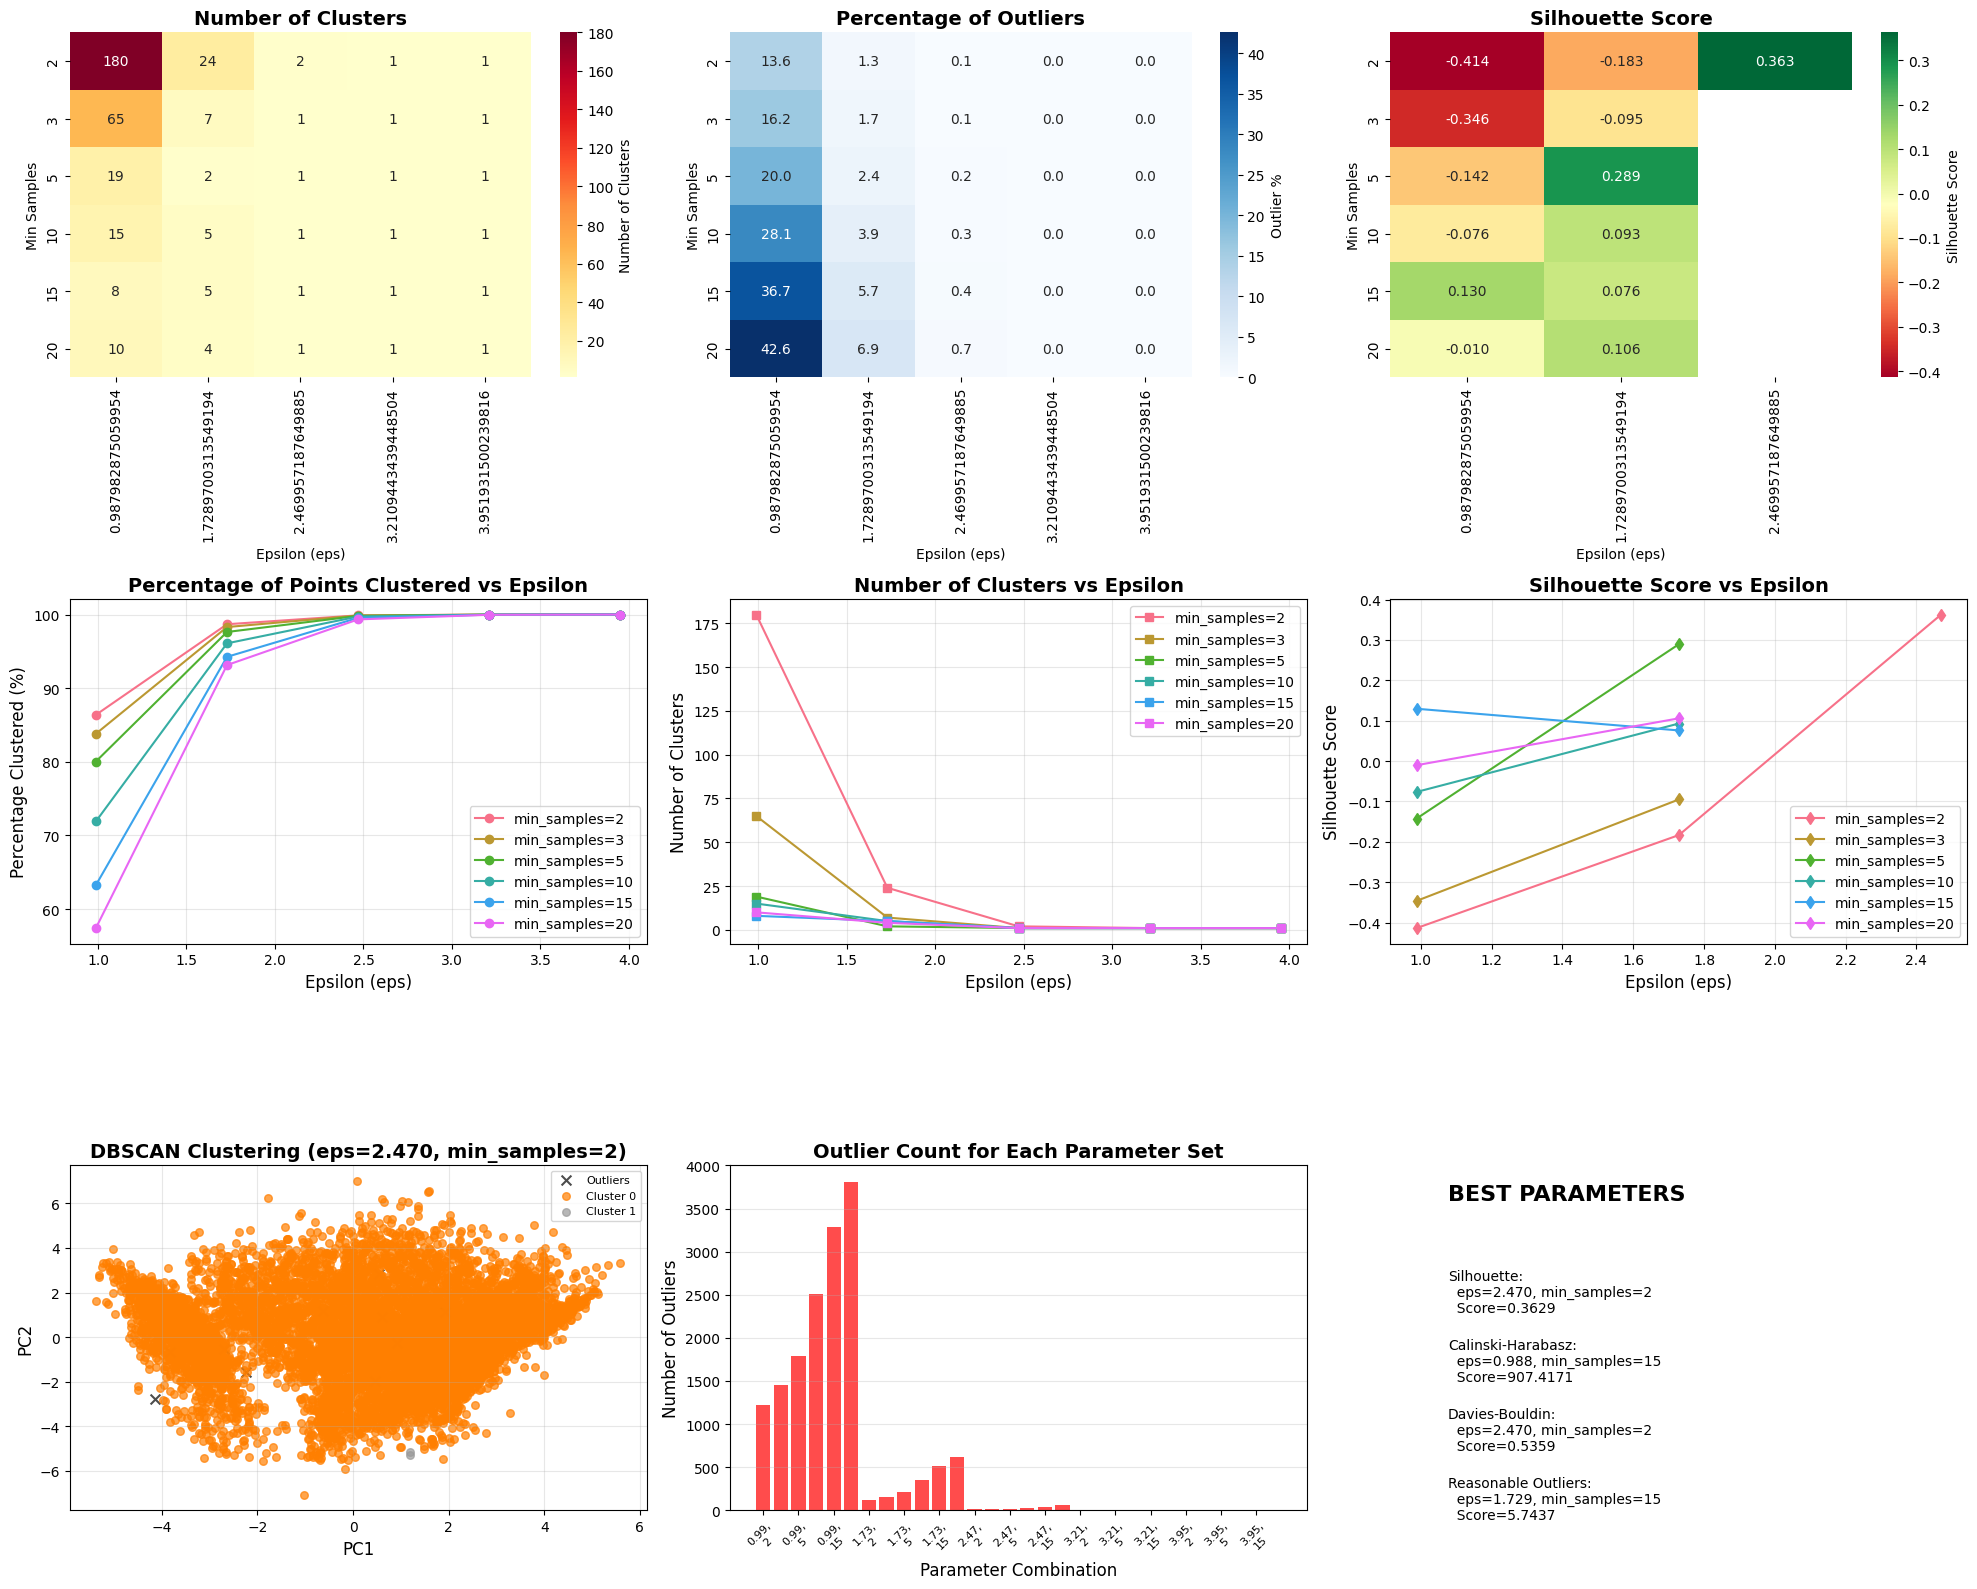


DBSCAN PARAMETER TESTING SUMMARY

OVERALL STATISTICS:
--------------------------------------------------
Mean outliers across all tests: 539.90
Median outliers across all tests: 20.00
Max outliers: 3810
Min outliers: 0

BEST PARAMETERS BY METRIC:
--------------------------------------------------
Silhouette:
  eps = 2.470, min_samples = 2
  Score = 0.3629
Calinski-Harabasz:
  eps = 0.988, min_samples = 15
  Score = 907.4171
Davies-Bouldin:
  eps = 2.470, min_samples = 2
  Score = 0.5359
Reasonable Outliers:
  eps = 1.729, min_samples = 15
  Outliers = 5.7%

OUTLIER ANALYSIS:
--------------------------------------------------
Average outlier percentage: 6.03%
Min outlier percentage: 0.00%
Max outlier percentage: 42.57%

RECOMMENDATIONS:
--------------------------------------------------
To choose the best parameters, consider:
1. Balance between cluster quality metrics and outlier detection
2. Domain knowledge about expected outlier proportion
3. The 'Reasonable Outliers' metric sugges

In [47]:
#PCA to DBSCAN
results_df, best_params, models = test_dbscan_parameters(df_pca)

In [48]:
#dbscan: PCA
#eps = 2.470, min_samples = 2
db = DBSCAN(eps=2.4699571, min_samples=2)
labels_db_pca = db.fit_predict(df_pca)

# Outliers/Noise points are automatically labeled as -1
n_clusters = len(set(labels_db_pca)) - (1 if -1 in labels_db_pca else 0)
n_noise = list(labels_db_pca).count(-1)

db_sil_pca = silhouette_score(df_pca, labels_db_pca)
db_cal_pca = calinski_harabasz_score(df_pca, labels_db_pca)
db_dav_pca = davies_bouldin_score(df_pca, labels_db_pca)

print(f"Estimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")
print(f"Percentage of noise points: {n_noise / len(df_pca) * 100:.2f}%")
print(f"Silhouette Score: {db_sil_pca:.4f}")
print(f"Calinkski-Harabasz Index: {db_cal_pca:.2f}")
print(f"davies_bouldin_score: {db_dav_pca}")

2026/08/29 21:24:33 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '51b953a102a743349e817bc2a3d39ef8', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:24:34 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:24:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:24:34 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:24:38 WARNI

Estimated number of clusters: 2
Estimated number of noise points: 10
Percentage of noise points: 0.11%
Silhouette Score: 0.2458
Calinkski-Harabasz Index: 7.90
davies_bouldin_score: 1.8821648558021236


In [49]:
clustering_df.loc['PCA to DBSCAN', 'K'] = n_clusters
clustering_df.loc['PCA to DBSCAN', 'Silhouette Score'] = db_sil_pca
clustering_df.loc['PCA to DBSCAN', 'Calinski-Harabasz'] = db_cal_pca
clustering_df.loc['PCA to DBSCAN', 'Davies-Bouldin'] = db_dav_pca
clustering_df.loc['PCA to DBSCAN', '%Outlers (for DBSCAN)'] = round(n_noise / len(scaled_df) * 100, 2) 

clustering_df

,K,Inertia,Calinski-Harabasz,Davies-Bouldin,Silhouette Score,%Outlers (for DBSCAN)
Baseline: K-means,7.0,66401.707403,1924.170448,1.387658,0.231918,NaN
Baseline: DBSCAN,2.0,NaN,8.087015,1.997351,0.261063,0.12
UMAP to K-Means,7.0,19778.548828,41640.312500,0.316696,0.769160,NaN
UMAP to DBSCAN,NaN,NaN,NaN,NaN,NaN,NaN
PCA to K-Means,7.0,55313.159144,2290.283310,1.278610,0.256406,NaN
PCA to DBSCAN,2.0,NaN,7.902107,1.882165,0.245776,0.11


2026/08/29 21:24:40 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '00a32f42e7e74473be76ceeccc1a9088', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:24:40 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:24:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:24:40 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:24:43 WARNI

Testing eps=0.118, min_samples=2...


2026/08/29 21:24:47 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:24:49 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '03a8014860fc4ba7afa08d9299dd4048', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:24:49 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature


  Clusters: 778, Outliers: 1320 (14.8%)
  Silhouette: 0.2411, CH: 14171.25, DB: 0.7241

Testing eps=0.118, min_samples=3...


2026/08/29 21:24:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:24:49 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:24:53 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:24:54 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '3b7278521f804df2b38d324016906a9d', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current skle

...

2026/08/29 21:26:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:26:58 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:27:02 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/08/29 21:27:03 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '99aa940ef3ba4d159c5d5cda8f862d6a', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current skle

  Clusters: 10, Outliers: 5 (0.1%)
  Silhouette: 0.7275, CH: 32777.03, DB: 0.4545

Testing eps=0.471, min_samples=20...


2026/08/29 21:27:07 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


  Clusters: 11, Outliers: 8 (0.1%)
  Silhouette: 0.5817, CH: 29664.63, DB: 0.5825



2026/08/29 21:27:08 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '2b66b667bfff4a1f8b39985cb1d82b58', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:27:09 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:27:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:27:09 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:27:12 WARNI

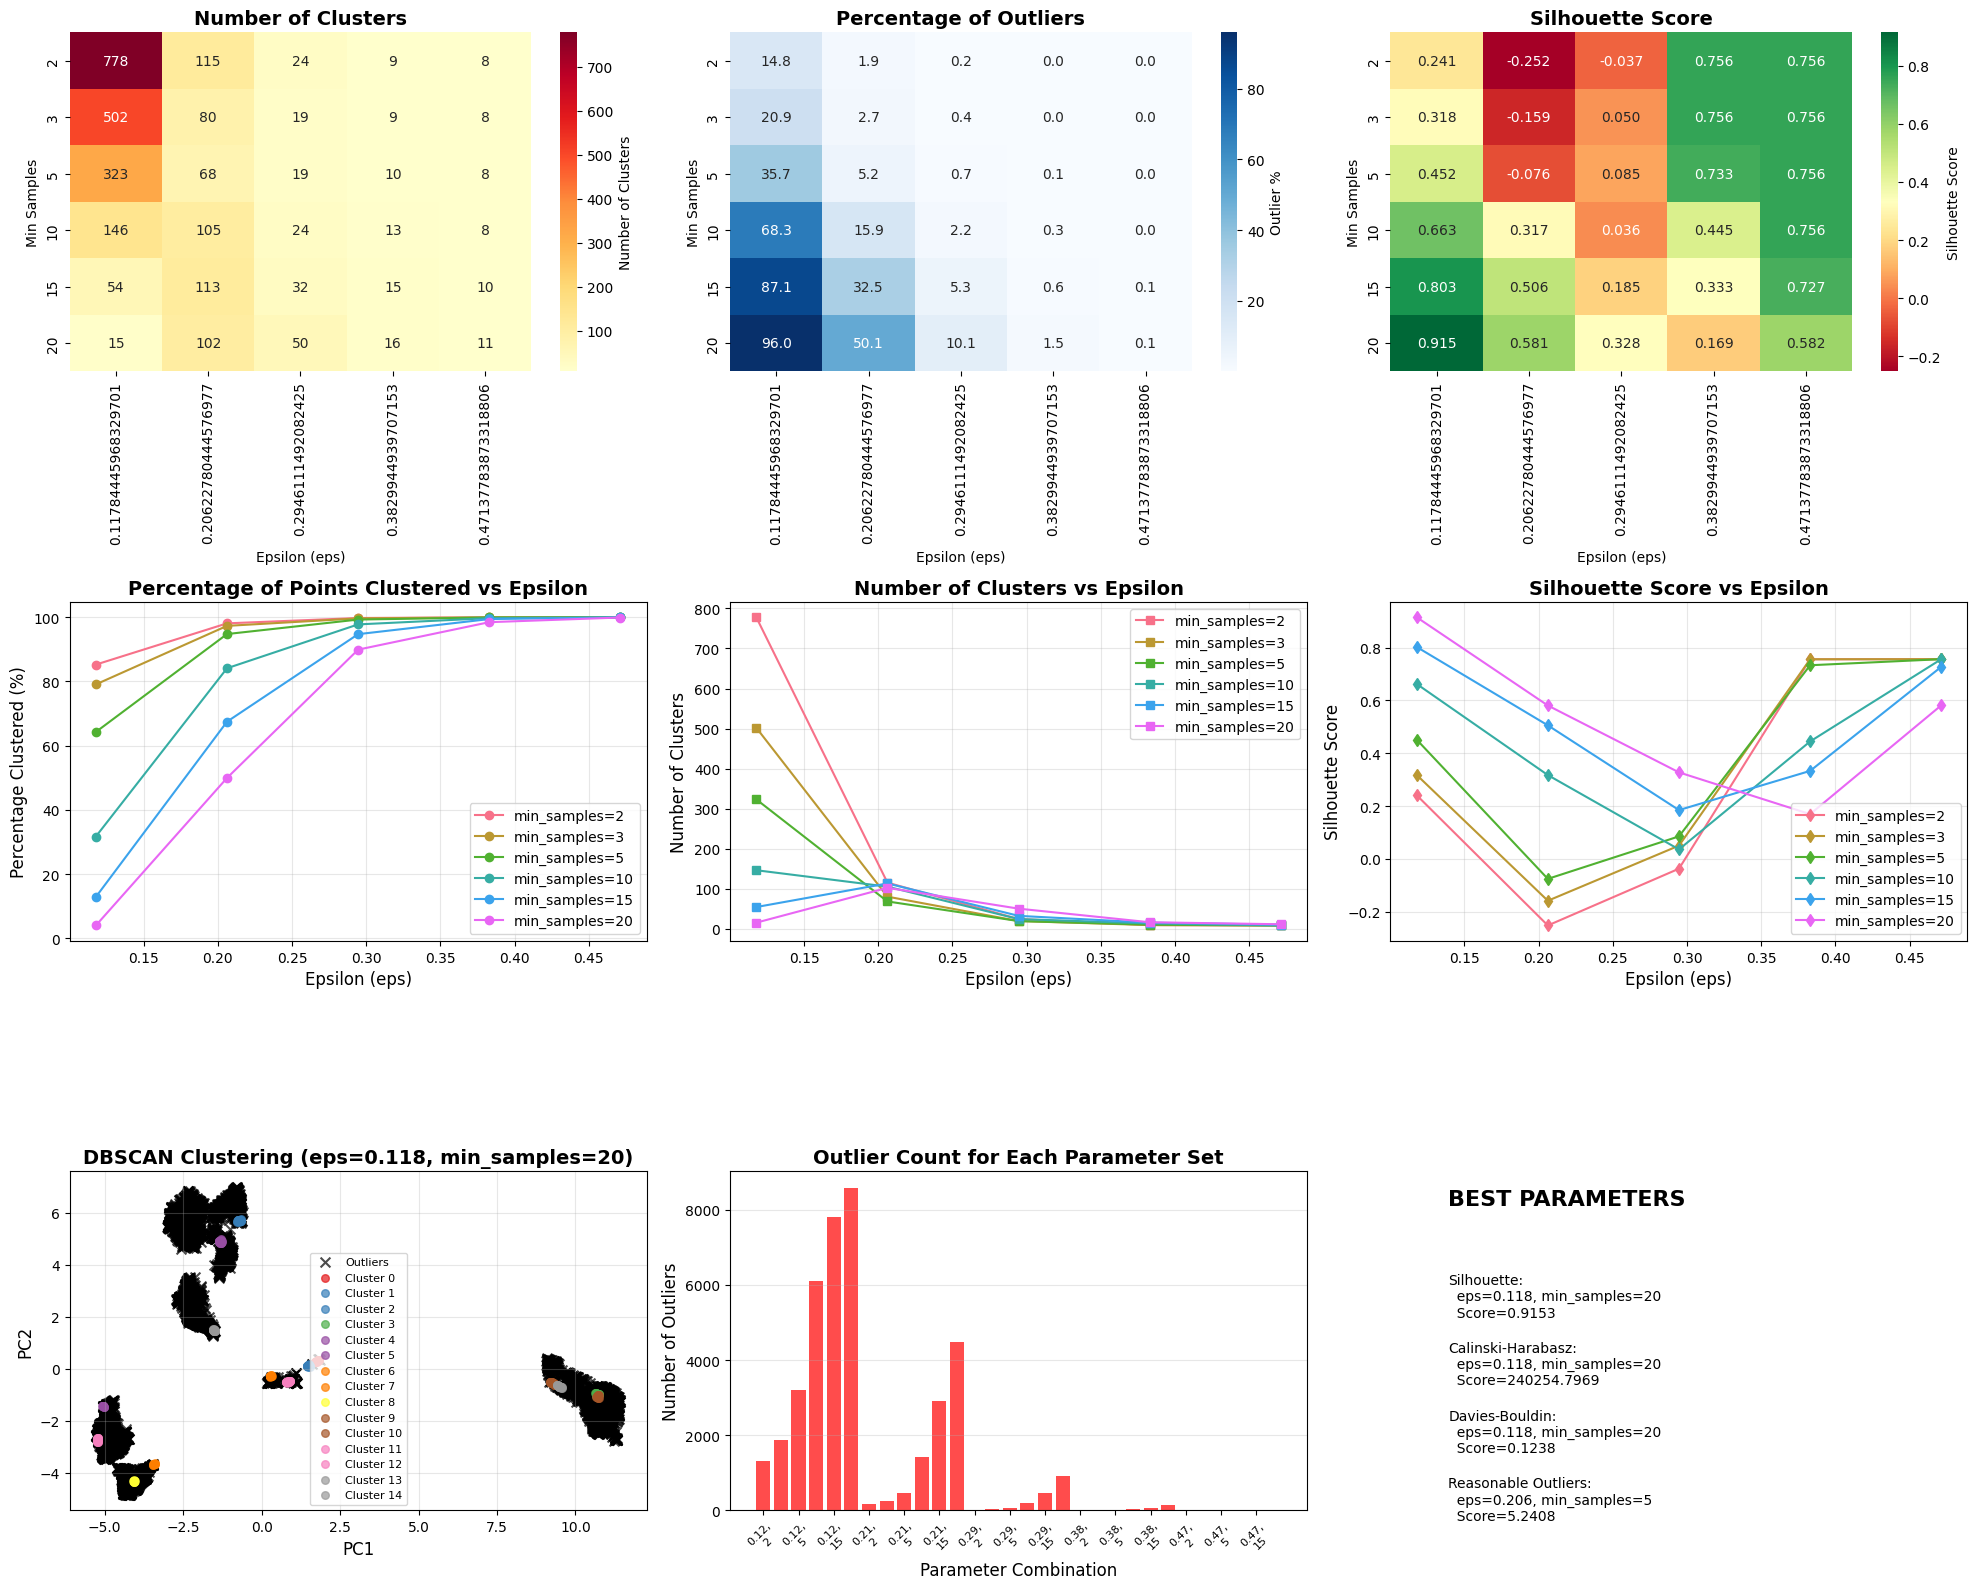


DBSCAN PARAMETER TESTING SUMMARY

OVERALL STATISTICS:
--------------------------------------------------
Mean outliers across all tests: 1350.80
Median outliers across all tests: 154.50
Max outliers: 8590
Min outliers: 1

BEST PARAMETERS BY METRIC:
--------------------------------------------------
Silhouette:
  eps = 0.118, min_samples = 20
  Score = 0.9153
Calinski-Harabasz:
  eps = 0.118, min_samples = 20
  Score = 240254.7969
Davies-Bouldin:
  eps = 0.118, min_samples = 20
  Score = 0.1238
Reasonable Outliers:
  eps = 0.206, min_samples = 5
  Outliers = 5.2%

OUTLIER ANALYSIS:
--------------------------------------------------
Average outlier percentage: 15.09%
Min outlier percentage: 0.01%
Max outlier percentage: 95.99%

RECOMMENDATIONS:
--------------------------------------------------
To choose the best parameters, consider:
1. Balance between cluster quality metrics and outlier detection
2. Domain knowledge about expected outlier proportion
3. The 'Reasonable Outliers' metric

In [50]:
#UMAP to DBSCAN
results_df, best_params, models = test_dbscan_parameters(reduced_df[0])

In [51]:
#dbscan: UMAP
#eps =0.383, min_samples = 3
db = DBSCAN(eps=0.383, min_samples=3)
labels = db.fit_predict(reduced_df[0])

# Outliers/Noise points are automatically labeled as -1
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

db_sil_umap = silhouette_score(reduced_df[0], labels)
db_cal_umap = calinski_harabasz_score(reduced_df[0], labels)
db_dav_umap = davies_bouldin_score(reduced_df[0], labels)

print(f"Estimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")
print(f"Percentage of noise points: {n_noise / len(reduced_df[0]) * 100:.2f}%")
print(f"Silhouette Score: {db_sil_umap:.4f}")
print(f"Calinkski-Harabasz Index: {db_cal_umap:.2f}")
print(f"davies_bouldin_score: {db_dav_umap}")

2026/08/29 21:27:17 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'd6dbcd7cf7084ab6a3177a6df54a90c6', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:27:17 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/08/29 21:27:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:27:17 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/08/29 21:27:21 WARNI

Estimated number of clusters: 9
Estimated number of noise points: 4
Percentage of noise points: 0.04%
Silhouette Score: 0.7535
Calinkski-Harabasz Index: 27722.98
davies_bouldin_score: 0.9349315553487291


In [52]:
clustering_df.loc['UMAP to DBSCAN', 'K'] = n_clusters
clustering_df.loc['UMAP to DBSCAN', 'Silhouette Score'] = db_sil_umap
clustering_df.loc['UMAP to DBSCAN', 'Calinski-Harabasz'] = db_cal_umap
clustering_df.loc['UMAP to DBSCAN', 'Davies-Bouldin'] = db_dav_umap
clustering_df.loc['UMAP to DBSCAN', '%Outlers (for DBSCAN)'] = round(n_noise / len(scaled_df) * 100, 2) 

clustering_df

,K,Inertia,Calinski-Harabasz,Davies-Bouldin,Silhouette Score,%Outlers (for DBSCAN)
Baseline: K-means,7.0,66401.707403,1924.170448,1.387658,0.231918,NaN
Baseline: DBSCAN,2.0,NaN,8.087015,1.997351,0.261063,0.12
UMAP to K-Means,7.0,19778.548828,41640.312500,0.316696,0.769160,NaN
UMAP to DBSCAN,9.0,NaN,27722.982422,0.934932,0.753496,0.04
PCA to K-Means,7.0,55313.159144,2290.283310,1.278610,0.256406,NaN
PCA to DBSCAN,2.0,NaN,7.902107,1.882165,0.245776,0.11


UMAP to K-Means has the best metrics all around. The outliers found (less than 1% for all instances of DBSCAN) are small. 

In [53]:
umap_labeled_df = pd.DataFrame(reduced_df[0])

kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
labels = kmeans.fit_predict(umap_labeled_df.copy())

df['kmeans_labels'] = labels
df


2026/08/29 21:27:22 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'afff253618f14b9e98738f441fde4888', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/08/29 21:27:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/29 21:27:26 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,kmeans_labels
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,3
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.452292,0.000000,12,5
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,1
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,312.452292,0.000000,6,1
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,1
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,0


---
### **3. Cluster Profiles**


In [54]:
pd.set_option('display.max_rows', None)
df.groupby('kmeans_labels').describe().T

kmeans_labels                                      0             1  \
BALANCE                          count   1987.000000   1766.000000   
                                 mean    2207.725649    412.334929   
                                 std     2124.042947    937.779838   
                                 min        0.000000      0.000000   
                                 25%      825.277817     19.932876   
                                 50%     1502.292117     59.082943   
                                 75%     2880.480017    315.068229   
                                 max    14581.459140  11670.179850   
BALANCE_FREQUENCY                count   1987.000000   1766.000000   
                                 mean       0.901043      0.804686   
                                 std        0.203511      0.281091   
                                 min        0.000000      0.000000   
                                 25%        0.909091      0.636364   
                                 50%        1.000000      1.000000   
                                 75%        1.000000      1.000000   
                                 max        1.000000      1.000000   
PURCHASES                        count   1987.000000   1766.000000   
                                 mean       0.174555    547.634530   
                                 std        3.301176    894.659131   
                                 min        0.000000      0.000000   
                                 25%        0.000000    165.842500   
                                 50%        0.000000    333.330000   
                                 75%        0.000000    611.100000   
                                 max      118.050000  22500.000000   
ONEOFF_PURCHASES                 count   1987.000000   1766.000000   
                                 mean       0.011007      1.138862   
                                 std        0.403036     18.599773   
                                 min        0.000000      0.000000   
                                 25%        0.000000      0.000000   
                                 50%        0.000000      0.000000   
                                 75%        0.000000      0.000000   
                                 max       17.800000    669.000000   
INSTALLMENTS_PURCHASES           count   1987.000000   1766.000000   
                                 mean       0.207307    547.524020   
                                 std        3.630571    896.056606   
                                 min        0.000000      0.000000   
                                 25%        0.000000    163.637500   
                                 50%        0.000000    333.330000   
                                 75%        0.000000    614.197500   
                                 max      118.050000  22500.000000   
CASH_ADVANCE                     count   1987.000000   1766.000000   
                                 mean    2017.594195      0.892642   
                                 std     2527.717852     23.148527   
                                 min       18.042768      0.000000   
                                 25%      376.484937      0.000000   
                                 50%     1221.854430      0.000000   
                                 75%     2717.719705      0.000000   
                                 max    26194.049540    879.373487   
PURCHASES_FREQUENCY              count   1987.000000   1766.000000   
                                 mean       0.000815      0.715581   
                                 std        0.009856      0.298869   
                                 min        0.000000      0.083333   
                                 25%        0.000000      0.500000   
                                 50%        0.000000      0.833333   
                                 75%        0.000000      1.000000   
                                 max        0.250000      1.000000   
ONEOFF_PUR

In [55]:
pd.reset_option('display.max_rows')

In [56]:
df.groupby('kmeans_labels').agg('mean')

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
kmeans_labels,,,,,,,,,,,,,,,,,
0,2207.725649,0.901043,0.174555,0.011007,0.207307,2017.594195,0.000815,0.000297,0.000601,0.276393,6.451938,0.011575,4050.083879,1731.096140,1025.114506,0.046090,11.358832
1,412.334929,0.804686,547.634530,1.138862,547.524020,0.892642,0.715581,0.001510,0.680735,0.000260,0.004530,12.065119,3109.645178,764.770759,759.026636,0.316111,11.501699
2,2789.873763,0.970501,1524.766657,811.956980,713.034632,2096.171688,0.747575,0.274697,0.630523,0.284029,7.278907,25.248774,5400.848711,2726.854502,1301.192622,0.057752,11.548003
3,778.311853,0.778755,895.282047,894.781062,0.590019,4.047289,0.359600,0.358000,0.001837,0.001648,0.022749,7.952607,4434.512423,1295.058989,518.365233,0.149545,11.581043
4,1216.749801,0.939527,2508.911949,1536.260831,972.679789,1.091108,0.817324,0.465411,0.651600,0.000675,0.008777,34.916910,5754.231608,2326.024693,542.753587,0.262784,11.827384
5,682.026216,0.452693,413.165250,285.158667,128.006583,683.575998,0.273434,0.123744,0.174290,0.081996,1.745833,5.595833,3920.208333,0.779150,311.615995,0.000000,11.020833
6,2407.472407,0.940090,658.770039,658.453464,0.734444,2076.789152,0.280659,0.279700,0.001613,0.303062,7.062745,6.388235,4603.169340,1945.729988,1017.726249,0.047886,11.290196


In [57]:
df.groupby('kmeans_labels').agg('median')

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
kmeans_labels,,,,,,,,,,,,,,,,,
0,1502.292117,1.000000,0.00,0.00,0.00,1221.854430,0.000000,0.000000,0.000000,0.25,4.0,0.0,3000.0,804.616908,486.647187,0.000,12.0
1,59.082943,1.000000,333.33,0.00,333.33,0.000000,0.833333,0.000000,0.750000,0.00,0.0,10.0,2500.0,436.596689,165.185407,0.125,12.0
2,1923.886805,1.000000,874.98,242.89,421.96,1153.945828,0.833333,0.166667,0.666667,0.25,4.0,16.0,4500.0,1577.510657,790.847301,0.000,12.0
3,262.106758,1.000000,449.32,449.32,0.00,0.000000,0.250000,0.250000,0.000000,0.00,0.0,4.0,3000.0,614.163281,194.636798,0.000,12.0
4,532.334517,1.000000,1562.43,789.22,554.03,0.000000,0.916667,0.416667,0.666667,0.00,0.0,24.0,5000.0,1363.695769,212.082883,0.000,12.0
5,52.893908,0.222222,97.25,0.00,0.00,0.000000,0.100000,0.000000,0.000000,0.00,0.0,2.0,3000.0,0.000000,312.452292,0.000,12.0
6,1669.992809,1.000000,293.26,293.26,0.00,1189.533753,0.166667,0.166667,0.000000,0.25,5.0,3.0,3200.0,1133.874141,556.407341,0.000,12.0


In [58]:
#aggregate by interquartile range
df.groupby('kmeans_labels').agg(lambda x: x.quantile(0.75) - x.quantile(0.25))

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
kmeans_labels,,,,,,,,,,,,,,,,,
0,2055.202200,0.090909,0.0000,0.0000,0.000,2341.234768,0.000000,0.000000,0.000000,0.248484,6.0,0.00,4500.0,1390.102263,743.877614,0.000000,0.00
1,295.135354,0.363636,445.2575,0.0000,450.560,0.000000,0.500000,0.000000,0.583333,0.000000,0.0,6.00,2700.0,635.848349,124.272274,0.636364,0.00
2,2980.146007,0.000000,1471.3650,983.7900,714.745,2234.350776,0.500000,0.416667,0.508333,0.333334,7.0,23.00,5500.0,2280.071513,1153.932138,0.000000,0.00
3,1053.083414,0.454545,873.5700,873.6900,0.000,0.000000,0.462122,0.462122,0.000000,0.000000,0.0,10.00,4900.0,1079.903262,287.205596,0.090909,0.00
4,1341.202156,0.000000,2097.4700,1494.9200,944.070,0.000000,0.333333,0.583333,0.583333,0.000000,0.0,29.00,5000.0,1911.001072,367.577480,0.500000,0.00
5,582.752509,0.909091,394.2325,257.7775,96.555,906.283964,0.333333,0.125000,0.166667,0.111111,2.0,5.25,3325.0,0.000000,0.000000,0.000000,0.25
6,2310.439299,0.000000,600.2400,600.2400,0.000,2420.088449,0.250000,0.250000,0.000000,0.250000,7.0,6.00,4550.0,1720.900453,890.767587,0.000000,0.00


In [67]:
df.groupby('kmeans_labels').var()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
kmeans_labels,,,,,,,,,,,,,,,,,
0,4.511558e+06,0.041417,1.089776e+01,1.624381e-01,1.318105e+01,6.389358e+06,0.000097,0.000025,0.000072,0.040809,73.266949,0.016482,1.082464e+07,7.772022e+06,7.113886e+06,0.019695,2.243279
1,8.794310e+05,0.079012,8.004150e+05,3.459516e+02,8.029174e+05,5.358543e+02,0.089323,0.000159,0.091600,0.000025,0.009045,154.903972,7.307787e+06,1.523741e+06,1.214095e+07,0.137311,1.912462
2,6.827764e+06,0.007947,5.184563e+06,2.946920e+06,9.949435e+05,8.620384e+06,0.072475,0.091830,0.094039,0.043041,83.373769,812.265558,1.639411e+07,1.472208e+07,3.797698e+06,0.022913,1.705092
3,1.413531e+06,0.086173,2.031464e+06,2.032084e+06,3.650766e+01,3.324244e+03,0.097893,0.098410,0.000227,0.000179,0.033638,194.870617,1.318389e+07,6.123347e+06,2.813777e+06,0.094298,1.528293
4,3.323881e+06,0.021147,1.239986e+07,7.862879e+06,1.810359e+06,2.173657e+02,0.054597,0.110072,0.095976,0.000069,0.013389,1347.734310,1.614183e+07,1.070922e+07,1.156322e+06,0.129552,0.587868
5,1.898330e+06,0.170872,7.014738e+05,4.579013e+05,1.136095e+05,1.589593e+06,0.119947,0.060508,0.098239,0.020031,11.462326,112.392451,9.406713e+06,8.495381e+01,1.678539e+02,0.000000,3.585338
6,5.240725e+06,0.019558,2.283227e+06,2.282465e+06,9.410417e+01,6.279319e+06,0.064499,0.064505,0.000217,0.046436,61.318047,189.072898,1.208958e+07,8.527774e+06,2.685233e+06,0.017660,2.546566


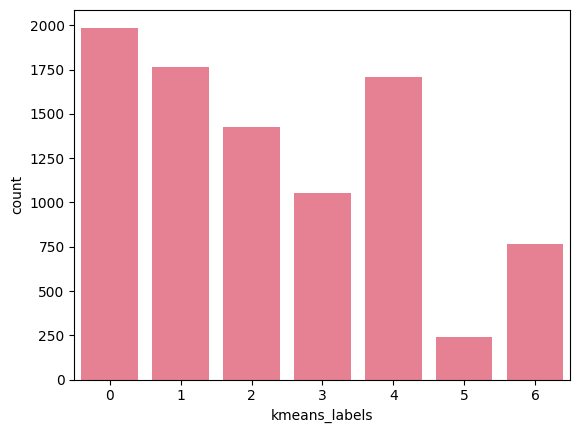

In [59]:
sns.countplot(data=df, x="kmeans_labels")
plt.show()

In [60]:
df.to_csv('cc_data_labeled.csv')

Note: Refer to the documentation for the cluster profiles

From the analysis, cluster 0 and 2 are very similar and that they both have high cash advances with occasional purchases. To test if the two can be merged as one cluster, their spread and distance in a standardized feature space (without UMAP) can be tested. 

In [72]:
from scipy.spatial.distance import pdist, squareform

cols = ['BALANCE','BALANCE_FREQUENCY','PURCHASES','ONEOFF_PURCHASES','INSTALLMENTS_PURCHASES',
        'CASH_ADVANCE','PURCHASES_FREQUENCY','ONEOFF_PURCHASES_FREQUENCY',
        'PURCHASES_INSTALLMENTS_FREQUENCY','CASH_ADVANCE_FREQUENCY','CASH_ADVANCE_TRX',
        'PURCHASES_TRX','CREDIT_LIMIT','PAYMENTS','MINIMUM_PAYMENTS','PRC_FULL_PAYMENT','TENURE']
X = df[cols].fillna(df[cols].median())
Xs = StandardScaler().fit_transform(X)

labels = df['kmeans_labels'].values

# 1. Compute centroids per cluster
df_x = pd.DataFrame(Xs)
df_x['label'] = labels
centroids = df_x.groupby('label').mean()

# 2. Pairwise centroid distances (Euclidean)
dist_matrix = pd.DataFrame(
    squareform(pdist(centroids.values)),
    index=centroids.index, columns=centroids.index
)
print("Centroid distance matrix:\n", dist_matrix.round(2))

# 3. Within-cluster spread: mean distance of each point to its OWN centroid
spread = {}
for c in centroids.index:
    pts = df_x[df_x.label == c].drop(columns='label').values
    cen = centroids.loc[c].values
    d = np.linalg.norm(pts - cen, axis=1)
    spread[c] = {'n': len(pts), 'mean_dist_to_centroid': d.mean(), 'std': d.std()}
spread_df = pd.DataFrame(spread).T
print("\nWithin-cluster spread:\n", spread_df.round(2))

# 4. The actual diagnostic: is the between-cluster gap smaller than within-cluster spread?
gap = dist_matrix.loc[0, 6]
print(f"\n0-6 centroid gap: {gap:.2f}")
print(f"Cluster 0 spread: {spread_df.loc[0,'mean_dist_to_centroid']:.2f}")
print(f"Cluster 6 spread: {spread_df.loc[6,'mean_dist_to_centroid']:.2f}")
print("→ Over-segmented" if gap < spread_df.loc[[0,6],'mean_dist_to_centroid'].min() else "→ Reasonably separated")

Centroid distance matrix:
 label     0     1     2     3     4     5     6
label                                          
0      0.00  3.53  3.11  2.73  4.42  2.73  1.33
1      3.53  0.00  3.04  2.53  2.58  2.71  3.51
2      3.11  3.04  0.00  3.31  2.54  3.71  2.34
3      2.73  2.53  3.31  0.00  2.85  1.99  2.41
4      4.42  2.58  2.54  2.85  0.00  3.89  3.72
5      2.73  2.71  3.71  1.99  3.89  0.00  2.90
6      1.33  3.51  2.34  2.41  3.72  2.90  0.00

Within-cluster spread:
         n  mean_dist_to_centroid   std
0  1987.0                   2.64  1.85
1  1766.0                   2.60  1.74
2  1427.0                   3.59  2.32
3  1055.0                   2.68  1.45
4  1709.0                   3.37  2.55
5   240.0                   2.96  1.09
6   765.0                   2.99  1.82

0-6 centroid gap: 1.33
Cluster 0 spread: 2.64
Cluster 6 spread: 2.99
→ Over-segmented


The over segmentation between clusters 0 and 6, seen the low centroid distance of 1.33, which is less than the within-cluster spread of both clusters, 0 and 6, implies overlap between the two. This is also seen in the cluster profiles, analyzing the mean and median of their features respectively. Hence, the two clusters are combined. To do so without affecting the pre-processing and clustering pipeline, and since the clustering metrics from UMAP establish that k=7 for k-means is ideal, the clustering algorithm still has k=7 however all new entries that are part of cluster 6 become grouped into cluster 0. 

In [74]:
#group kmeans cluster = 6 and 0 as one
df.loc[df['kmeans_labels'] == 6, 'kmeans_labels'] = 0

df['kmeans_labels'].value_counts()

kmeans_labels
0    2752
1    1766
4    1709
2    1427
3    1055
5     240
Name: count, dtype: int64

---
### **4. Multiple Model Training for Classification**


---
### **5. Performance Metrics**


---
### **6. Conclusion**
